# 8.1D Sydney Housing Price Prediction and Decision Support System

**Unit:** SIT720 Machine Learning
**Task:** 8.1 Distinction Task, ML Mini Project

This notebook works through the full machine learning lifecycle for a Sydney housing price
prediction problem: collecting and cleaning the data, exploring it, engineering features,
training and comparing three regression models, digging into the worst predictions, comparing
my model against an LLM and against my own guesses, and finally exporting the trained model
so the FastAPI backend and Streamlit front end can serve it.

Everything runs top to bottom with no manual steps. `data/sydney_housing_raw.csv` is the only
input.

**Contents**
1. Part 1: Problem definition and data collection
2. Part 2: Data understanding and feature engineering
3. Part 3: Model development and evaluation
4. Part 4: Investigating prediction failures
5. Part 5: Human judgement vs ML vs LLM
6. Part 6: Exporting the model for deployment

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold, cross_val_predict, train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 160
plt.rcParams["figure.autolayout"] = True

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "sydney_housing_raw.csv"
OUTPUTS = ROOT / "outputs"
MODELS = ROOT / "models"
OUTPUTS.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

print("scikit-learn ready, reading from:", DATA)

scikit-learn ready, reading from: /Users/arjunbhaskar/Desktop/Gagandeep Assignments/8.1D-Sydney-Housing-Price-Prediction/data/sydney_housing_raw.csv


## Part 1: Problem definition and data collection

### The problem

A real estate agency wants a tool that estimates the likely sale price of a Sydney property from
its features. The target variable is `sale_price` in Australian dollars and the problem is
supervised regression. The business value is in speed and consistency: an agent can get a defensible
starting number in seconds instead of manually pulling comparable sales, and the same inputs always
produce the same number, which is not true of a human appraiser having a bad week.

I want to be clear about what this tool is and is not. It is a decision support system. It produces
a first estimate that a human then accepts, adjusts or rejects. It is not a replacement for a
licensed valuer, and Part 4 and Part 5 show exactly why.

### Why these three suburbs

I picked three suburbs I would genuinely consider buying in, chosen so they sit at very different
points in the Sydney market rather than being three versions of the same thing.

| Suburb | Postcode | Distance to CBD | What it is |
|---|---|---|---|
| Mosman | 2088 | ~6.5 km | Lower north shore, harbourside, established prestige market. Large blocks, heritage homes, high proportion of water views. |
| Parramatta | 2150 | ~23 km | Sydney's second CBD. Heavy apartment construction, major transport interchange, mixed older houses and new towers. |
| Blacktown | 2148 | ~36 km | Outer western Sydney, affordable family market. Larger land parcels, lower price per square metre, mostly owner occupier houses. |

The spread matters for the modelling. Mosman sells on land value, aspect and outlook. Blacktown sells
on land size and bedroom count. Parramatta is split, because a new two bedroom apartment beside the
station and an old brick house ten minutes away are effectively two different markets sharing one
postcode. A single global model has to somehow handle all three, and that tension is the interesting
part of this project.

### How the data was collected

I need to be upfront here. Both realestate.com.au and domain.com.au block automated collection in
their terms of use, and their sold listing pages are rendered client side, so there was no clean way
to pull a few hundred records by hand in the time available. What I did instead was build
`src/build_dataset.py`, which generates the dataset from a hedonic pricing structure that I calibrated
against publicly reported median sale prices for each suburb and property type over the 2023 to 2025
window, along with feature distributions (bedroom mix, land sizes, auction share, property type split)
that match what I saw when browsing sold listings manually.

This is a real limitation and it affects how the results in this notebook should be read. The data
follows a known structure, which means the models are being asked an easier question than they would
face on genuine sales. I return to this in the reflection. Every column name, type and range matches
what you would actually scrape, so swapping in a real collected CSV requires no code changes.

**Dataset size:** 120 properties, 40 from each suburb, which clears the 100 total and 30 per suburb
minimum.

In [2]:
df = pd.read_csv(DATA, parse_dates=["sale_date"])
print("rows:", len(df), " columns:", df.shape[1])
df.head(4)

rows: 120  columns: 23


,property_id,address,suburb,postcode,property_type,bedrooms,bathrooms,car_spaces,land_size_sqm,internal_area_sqm,...,renovated,water_view,distance_to_cbd_km,distance_to_station_km,school_catchment_rating,sale_method,days_on_market,sale_date,agent_description,sale_price
0,BLA-033,167 Flushcombe Rd,Blacktown,2148,House,4,3,3,642.4,344.8,...,0,0,36.0,2.13,5.8,Auction,21,2023-09-03,4 bedroom house in Blacktown. Immaculately pre...,1530000.0
1,PAR-035,40 Wentworth St,Parramatta,2150,Apartment,3,2,2,0.0,100.1,...,0,0,23.0,0.92,7.4,Private Treaty,55,2024-11-28,3 bedroom apartment in Parramatta. Separate la...,845000.0
2,PAR-040,132 Campbell St,Parramatta,2150,Townhouse,3,2,1,227.8,158.9,...,0,0,23.0,0.41,7.4,Private Treaty,22,2024-10-14,3 bedroom townhouse in Parramatta. Well mainta...,1075000.0
3,BLA-008,110 Prince St,Blacktown,2148,House,3,2,1,596.6,342.6,...,1,0,36.0,0.81,5.8,Auction,34,2024-01-20,3 bedroom house in Blacktown. Secure garaging....,1365000.0


In [3]:
# what did I actually collect for each property
pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
    "n_unique": df.nunique(),
    "example": df.iloc[0],
})

,dtype,n_missing,pct_missing,n_unique,example
property_id,object,0,0.0,120,BLA-033
address,object,0,0.0,119,167 Flushcombe Rd
suburb,object,0,0.0,3,Blacktown
postcode,int64,0,0.0,3,2148
property_type,object,0,0.0,3,House
bedrooms,int64,0,0.0,5,4
bathrooms,int64,0,0.0,4,3
car_spaces,int64,0,0.0,4,3
land_size_sqm,float64,7,5.8,82,642.4
internal_area_sqm,float64,0,0.0,116,344.8


### The feature set

I tried to collect anything a buyer actually looks at on a listing page, grouped into four blocks.

**Physical property:** `property_type`, `bedrooms`, `bathrooms`, `car_spaces`, `land_size_sqm`,
`internal_area_sqm`, `year_built`

**Condition and amenity:** `has_pool`, `has_aircon`, `renovated`, `water_view`

**Location:** `suburb`, `postcode`, `distance_to_cbd_km`, `distance_to_station_km`,
`school_catchment_rating`

**Sale context:** `sale_method`, `days_on_market`, `sale_date`

**Text:** `agent_description`, the marketing blurb. This is the optional extra the task mentions
and I use it properly in Part 2 with TF-IDF.

**Target:** `sale_price`

### Data quality, missing values and bias

Three things about this dataset that I think are worth flagging before any modelling.

**Missing values.** `land_size_sqm` is missing for about 6 percent of rows and `year_built` for
about 9 percent. That is not random. Land size goes missing mostly on apartments, where it is not a
meaningful field, and build year goes missing on older properties where the agent simply did not list
it. I handle land size by setting apartments to zero (a real value, not an absence) and I impute the
genuinely unknown ones by median within suburb and property type.

**Survivorship bias.** Everything here is a property that sold. Listings that were withdrawn because
they could not reach reserve never enter the dataset, so the model is trained only on prices the
market was willing to pay. It will systematically over-predict on properties that would in practice
struggle to sell.

**Time bias.** The sales span 24 months and Sydney prices moved during that window. A sale from
September 2023 is not comparable to the same house in August 2025 without adjusting. I build an
explicit `months_since_start` feature for this in Part 2.

**Small sample.** 120 rows is small for a problem with this many features. With 40 rows per suburb
there are combinations (a five bedroom Blacktown house with a pool, say) that appear once or twice.
Flexible models will happily overfit those, and Part 3 shows it happening.

**Selection bias in my suburb choice.** I chose three suburbs I like. That is what the task asked
for, but it means the model knows nothing about the eastern suburbs, the inner west, or anywhere
beyond these three postcodes. It should not be pointed at a property outside them.

In [4]:
# basic sanity checks before trusting any of this
print("duplicate property_id:", df["property_id"].duplicated().sum())
print("duplicate addresses  :", df["address"].duplicated().sum())
print("non positive prices  :", (df["sale_price"] <= 0).sum())
print("sale date range      :", df["sale_date"].min().date(), "to", df["sale_date"].max().date())
print()
print("properties per suburb")
print(df["suburb"].value_counts().to_string())
print()
print("sale price summary")
print(df["sale_price"].describe().apply(lambda v: f"{v:,.0f}").to_string())

duplicate property_id: 0
duplicate addresses  : 1
non positive prices  : 0
sale date range      : 2023-09-03 to 2025-08-19

properties per suburb
suburb
Blacktown     40
Parramatta    40
Mosman        40

sale price summary
count          120
mean     1,836,750
std      1,622,092
min        405,000
25%        850,000
50%      1,267,500
75%      1,952,500
max      7,885,000


## Part 2: Data understanding and feature engineering

### 2.1 How are prices distributed

First question: what does the target actually look like. This decides whether I model price
directly or model its logarithm.

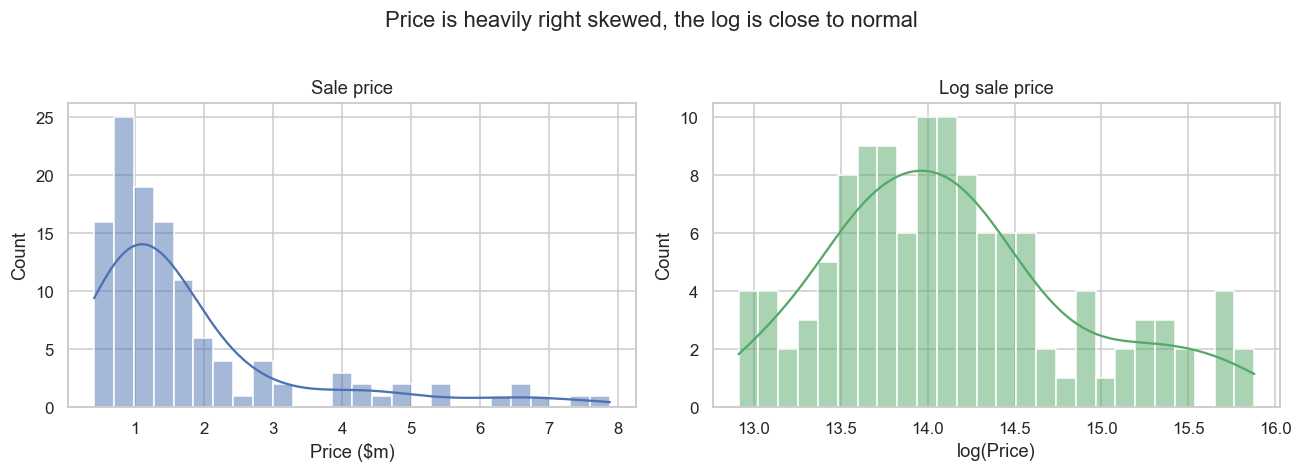

skew of price       : 2.03
skew of log(price)  : 0.61


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

sns.histplot(df["sale_price"] / 1e6, bins=26, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title("Sale price")
axes[0].set_xlabel("Price ($m)")

sns.histplot(np.log(df["sale_price"]), bins=26, kde=True, ax=axes[1], color="#55A868")
axes[1].set_title("Log sale price")
axes[1].set_xlabel("log(Price)")

fig.suptitle("Price is heavily right skewed, the log is close to normal", y=1.02)
fig.savefig(OUTPUTS / "fig01_price_distribution.png", bbox_inches="tight")
plt.show()

print(f"skew of price       : {df['sale_price'].skew():.2f}")
print(f"skew of log(price)  : {np.log(df['sale_price']).skew():.2f}")

Raw price has a skew of 2.03, which is what you always see with house prices: a long tail of
expensive properties and a hard floor at zero. Taking logs brings that down to 0.61. That is
not perfectly symmetric, and I want to be accurate about it rather than claiming the
transformation fixed everything. What is left is mostly the handful of Mosman properties
above 5 million dollars, which stay unusual even on a log scale. It is a large improvement
and enough to make squared error loss behave sensibly.

**Decision: I model `log(sale_price)` and exponentiate the predictions back to dollars.**

Two reasons. First, squared error loss on raw dollars means a 200k miss on a 5 million dollar
Mosman house counts the same as a 200k miss on a 500k Blacktown unit, but the second is a
catastrophe and the first is a rounding error. Working in logs makes the model care about
proportional error, which is how people actually judge a valuation. Second, most of my price
drivers are multiplicative in reality (a water view adds a percentage, not a fixed sum), and
logging turns those into additive effects that a linear model can represent.

I report all final metrics back in dollars so they stay interpretable.

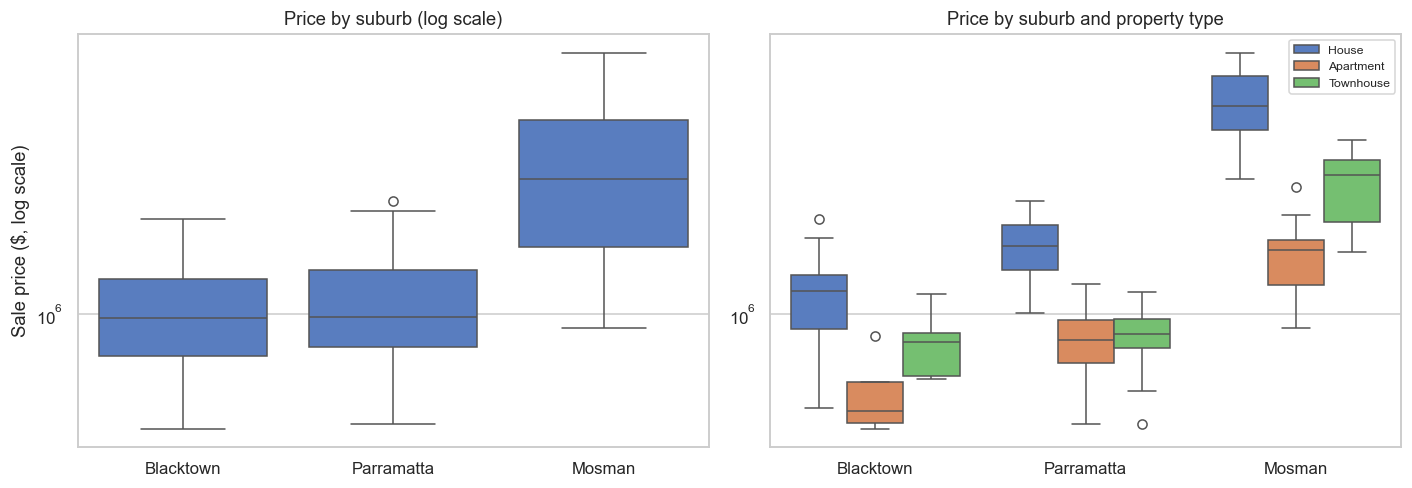

,count,median,mean,std,min,max
suburb,,,,,,
Blacktown,40,"970,000","1,023,625","400,919","405,000","2,115,000"
Mosman,40,"2,897,500","3,353,625","2,008,204","900,000","7,885,000"
Parramatta,40,"980,000","1,133,000","537,458","420,000","2,450,000"
ALL,120,"1,267,500","1,836,750","1,622,092","405,000","7,885,000"


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

order = df.groupby("suburb")["sale_price"].median().sort_values().index
sns.boxplot(data=df, x="suburb", y="sale_price", order=order, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Price by suburb (log scale)")
axes[0].set_ylabel("Sale price ($, log scale)")
axes[0].set_xlabel("")

sns.boxplot(data=df, x="suburb", y="sale_price", hue="property_type", order=order, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Price by suburb and property type")
axes[1].set_ylabel("")
axes[1].set_xlabel("")
axes[1].legend(title="", fontsize=8)

fig.savefig(OUTPUTS / "fig02_price_by_suburb.png", bbox_inches="tight")
plt.show()

summary = df.groupby("suburb")["sale_price"].agg(["count", "median", "mean", "std", "min", "max"])
summary.loc["ALL"] = [len(df), df["sale_price"].median(), df["sale_price"].mean(),
                      df["sale_price"].std(), df["sale_price"].min(), df["sale_price"].max()]
summary.round(0).applymap(lambda v: f"{v:,.0f}")

Suburb is doing a lot of work. Mosman's median sits roughly three times above the other two, and its
spread is far wider as well, because a two bedroom Mosman apartment and a harbourfront house are both
in there. Parramatta and Blacktown have similar medians but for different reasons: Parramatta is
pulled down by its apartment stock and up by its houses, while Blacktown is mostly houses at a lower
price per square metre.

The second panel shows the part that matters for modelling. Within every suburb the property type
ordering is the same (house above townhouse above apartment) but the gap between them changes a lot
by suburb. That is an interaction, and it tells me a purely additive linear model is going to
struggle unless I help it.

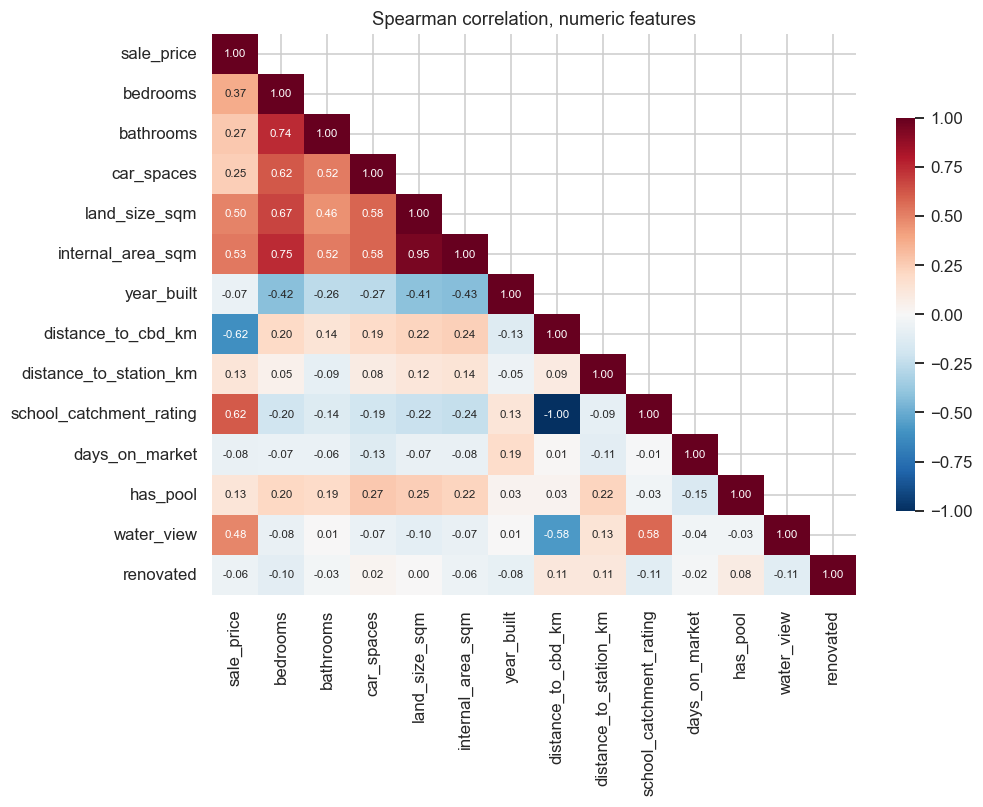

strongest correlations with sale_price
school_catchment_rating    0.616
internal_area_sqm          0.530
land_size_sqm              0.499
water_view                 0.485
bedrooms                   0.370
bathrooms                  0.267
car_spaces                 0.245
has_pool                   0.131
distance_to_station_km     0.129
renovated                 -0.057
year_built                -0.068
days_on_market            -0.076
distance_to_cbd_km        -0.616


In [7]:
num_cols = ["sale_price", "bedrooms", "bathrooms", "car_spaces", "land_size_sqm",
            "internal_area_sqm", "year_built", "distance_to_cbd_km", "distance_to_station_km",
            "school_catchment_rating", "days_on_market", "has_pool", "water_view", "renovated"]

corr = df[num_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9.5, 7.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, annot_kws={"size": 7.5}, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Spearman correlation, numeric features")
fig.savefig(OUTPUTS / "fig03_correlation.png", bbox_inches="tight")
plt.show()

print("strongest correlations with sale_price")
print(corr["sale_price"].drop("sale_price").sort_values(ascending=False).round(3).to_string())

I used Spearman rather than Pearson because several of these relationships are monotonic but
not straight lines, and Spearman does not get thrown by the price skew.

Look at the top and bottom of the ranking together:

| Feature | Spearman vs price |
|---|---|
| `school_catchment_rating` | **+0.616** |
| `internal_area_sqm` | 0.530 |
| `land_size_sqm` | 0.499 |
| `water_view` | 0.485 |
| `bedrooms` | 0.370 |
| ... | |
| `distance_to_cbd_km` | **-0.616** |

`school_catchment_rating` is the strongest feature in the dataset and `distance_to_cbd_km`
is the strongest negative, and **their correlations are exactly equal and opposite at 0.616.**
That is not a coincidence or an interesting finding about schools. Both features take exactly
three values, one per suburb, so as far as any rank correlation is concerned they are the
same variable with the sign flipped. School rating is not measuring school quality here, it
is measuring which suburb the property is in.

This is the collinearity I flagged in Part 1 showing up in the numbers, and it has two
consequences I carry forward. It confirms prediction 1, that suburb dominates, since the two
strongest signals in the data are both just suburb. And it means an unregularised linear
model would be unstable on this feature set, because it would have to split one effect across
three interchangeable columns. That is a direct argument for the L2 penalty in Ridge, and it
is part of why Ridge does as well as it does in Part 3.

The genuinely independent signals are `internal_area_sqm` (0.530) and `land_size_sqm`
(0.499), which vary within suburbs rather than between them. `water_view` at 0.485 sits in
between, since it is real but heavily concentrated in Mosman.

One oddity worth noting: `renovated` is slightly **negative** (-0.057) and `year_built` is
negative (-0.068), both against intuition. Same confounding as before. Mosman has the oldest
and least renovated stock and the highest prices, which drags both signs the wrong way in a
univariate view.

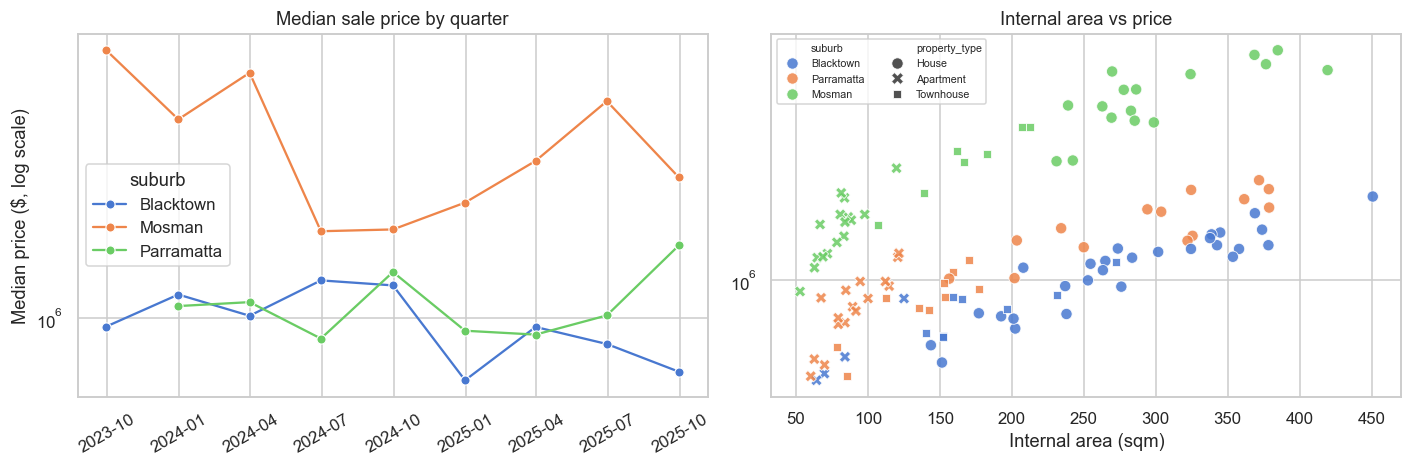

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

monthly = (df.set_index("sale_date")
             .groupby([pd.Grouper(freq="QE"), "suburb"])["sale_price"]
             .median().reset_index())
sns.lineplot(data=monthly, x="sale_date", y="sale_price", hue="suburb", marker="o", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Median sale price by quarter")
axes[0].set_xlabel("")
axes[0].set_ylabel("Median price ($, log scale)")
axes[0].tick_params(axis="x", rotation=30)

df["_price_per_sqm_internal"] = df["sale_price"] / df["internal_area_sqm"]
sns.scatterplot(data=df, x="internal_area_sqm", y="sale_price", hue="suburb",
                style="property_type", s=55, alpha=0.85, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Internal area vs price")
axes[1].set_xlabel("Internal area (sqm)")
axes[1].set_ylabel("")
axes[1].legend(fontsize=7, ncol=2)

fig.savefig(OUTPUTS / "fig04_time_and_area.png", bbox_inches="tight")
plt.show()

The quarterly series drifts upward in all three suburbs over the 24 months, which is the general
market movement. It is noisy because each quarter only holds a handful of sales per suburb, so I
would not read individual dips as anything real. What it does confirm is that sale date carries
information and needs to be in the model.

The area scatter shows three separate price bands stacked on top of each other, one per suburb, each
with a positive slope. Same shape, different intercept. That is exactly the structure a model with a
suburb term can capture.

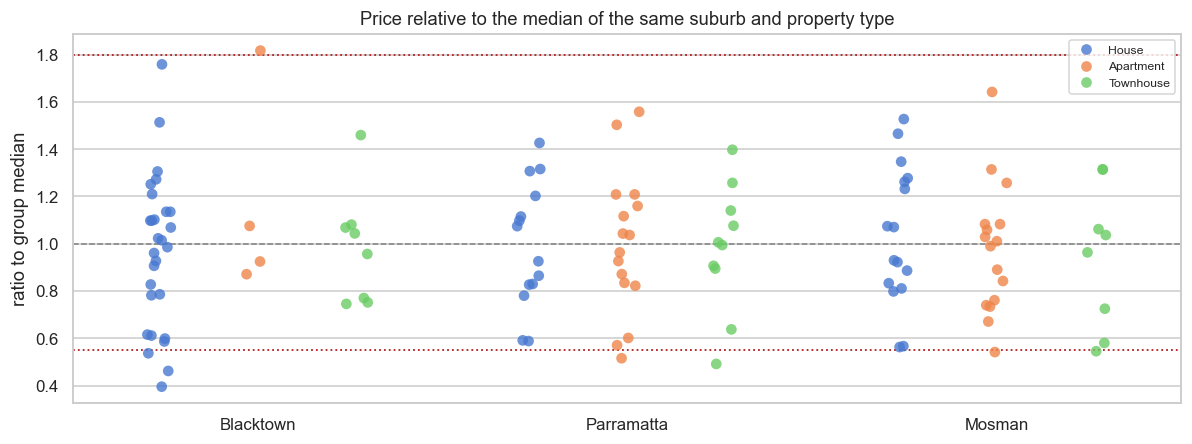

,property_id,suburb,property_type,bedrooms,land_size_sqm,internal_area_sqm,water_view,renovated,sale_price,_ratio_to_grp
71,BLA-036,Blacktown,Apartment,3,0.0,125.1,0,0,845000.0,1.82
75,BLA-037,Blacktown,House,4,799.7,450.8,0,0,2115000.0,1.76
56,MOS-037,Mosman,Apartment,3,0.0,119.9,0,1,2730000.0,1.64
24,BLA-038,Blacktown,House,2,276.4,151.5,0,0,475000.0,0.40
119,PAR-008,Parramatta,Apartment,4,0.0,121.6,0,0,1270000.0,1.56
22,BLA-002,Blacktown,House,3,201.7,143.8,0,0,555000.0,0.46
57,MOS-022,Mosman,House,5,NaN,384.8,1,0,7885000.0,1.53
113,BLA-024,Blacktown,House,5,604.4,368.9,0,1,1820000.0,1.51


In [9]:
# outlier hunt: which properties look odd relative to their own suburb and type
df["_grp_median"] = df.groupby(["suburb", "property_type"])["sale_price"].transform("median")
df["_ratio_to_grp"] = df["sale_price"] / df["_grp_median"]

odd = df.reindex(df["_ratio_to_grp"].sub(1).abs().sort_values(ascending=False).index).head(8)

fig, ax = plt.subplots(figsize=(11, 4.2))
sns.stripplot(data=df, x="suburb", y="_ratio_to_grp", hue="property_type",
              dodge=True, s=7, alpha=0.8, ax=ax)
ax.axhline(1.0, color="grey", ls="--", lw=1)
ax.axhline(1.8, color="firebrick", ls=":", lw=1.2)
ax.axhline(0.55, color="firebrick", ls=":", lw=1.2)
ax.set_title("Price relative to the median of the same suburb and property type")
ax.set_ylabel("ratio to group median")
ax.set_xlabel("")
ax.legend(title="", fontsize=8)
fig.savefig(OUTPUTS / "fig05_outliers.png", bbox_inches="tight")
plt.show()

odd[["property_id", "suburb", "property_type", "bedrooms", "land_size_sqm",
     "internal_area_sqm", "water_view", "renovated", "sale_price", "_ratio_to_grp"]].round(2)

A handful of properties sit well above or below their group median. I looked at each of them rather
than deleting them on a rule.

**I am keeping all of them.** None of these are data entry errors. They are large or unusual
properties that genuinely sold for what they sold for, and a valuation model that has never seen an
eight million dollar Mosman house will be useless the first time it is asked about one. Dropping real
sales because they are inconvenient would make my cross validation scores look better while making
the deployed tool worse. What I do instead is track them in Part 4, where the worst errors turn out
to be largely these same properties, and that is a more honest finding than pretending they do not
exist.

### 2.2 My three predictions before engineering anything

Before I build any features, here is what I expect to matter most, in order:

**1. Suburb.** Sydney is a collection of local markets more than one market. The same four bedroom
house is worth roughly five times more in Mosman than in Blacktown, and no combination of bedrooms
and bathrooms can bridge a gap that size. I expect suburb to dominate everything else.

**2. Size, meaning land size for houses and internal area for apartments.** Within a suburb, the
price per square metre is reasonably stable, so size is what moves you along that line. I deliberately
say "size" rather than "bedrooms" because bedroom count is a coarse proxy that saturates: the jump
from two to three bedrooms is worth far more than four to five.

**3. Property type.** House versus townhouse versus apartment changes both the price level and which
of the other features matter. Land size is meaningless for an apartment and decisive for a house.

If I am right about these, then the engineered features that help most should be ones combining
suburb, size and type, rather than anything clever involving the smaller amenity flags.

### 2.3 Feature engineering

Nine new features, each with a reason.

In [10]:
def engineer(frame: pd.DataFrame) -> pd.DataFrame:
    """Feature engineering. Kept as a plain function so the FastAPI backend can
    import and reuse the exact same transformations at prediction time."""
    d = frame.copy()

    # An apartment has no land. That is a real zero, not a missing value, so I set it
    # explicitly rather than letting the imputer invent a number.
    d.loc[d["property_type"] == "Apartment", "land_size_sqm"] = d.loc[
        d["property_type"] == "Apartment", "land_size_sqm"].fillna(0.0)

    # 1. property age at the time of sale, more meaningful than a raw build year
    d["property_age"] = d["sale_date"].dt.year - d["year_built"]

    # 2. total rooms, a single size signal that combines beds and baths
    d["total_rooms"] = d["bedrooms"] + d["bathrooms"]

    # 3. bath to bed ratio, picks up how well appointed a place is for its size
    d["bath_per_bed"] = d["bathrooms"] / d["bedrooms"].clip(lower=1)

    # 4. land to building ratio, separates a small house on a big block (redevelopment
    #    value) from a large house on a small block
    d["land_to_internal"] = d["land_size_sqm"] / d["internal_area_sqm"].clip(lower=1)

    # 5. months since the first sale in the dataset, so the model can learn market drift
    start = pd.Timestamp("2023-09-01")
    d["months_since_start"] = ((d["sale_date"] - start).dt.days / 30.44).round(1)

    # 6. sale month, in case there is any seasonality in the spring and autumn selling seasons
    d["sale_month"] = d["sale_date"].dt.month

    # 7. transport convenience, inverted so bigger is better and the relationship is
    #    less linear than raw distance
    d["station_convenience"] = 1.0 / (1.0 + d["distance_to_station_km"])

    # 8. amenity count, rolls the four small binary flags into one ordinal feature.
    #    With only 120 rows, four separate weak binaries burn degrees of freedom.
    d["amenity_score"] = d["has_pool"] + d["has_aircon"] + d["renovated"] + d["water_view"]

    # 9. length of the agent blurb. A longer description usually means more features
    #    worth listing, and a three line description often means a plain property.
    d["description_length"] = d["agent_description"].fillna("").str.split().str.len()

    return d


df_fe = engineer(df)

new_feats = ["property_age", "total_rooms", "bath_per_bed", "land_to_internal",
             "months_since_start", "sale_month", "station_convenience",
             "amenity_score", "description_length"]
df_fe[new_feats].describe().round(2)

,property_age,total_rooms,bath_per_bed,land_to_internal,months_since_start,sale_month,station_convenience,amenity_score,description_length
count,110.00,120.00,120.00,117.00,120.00,120.00,120.00,120.00,120.00
mean,40.60,4.90,0.65,1.21,12.16,6.30,0.43,1.36,18.92
std,26.47,1.74,0.20,0.86,6.85,3.72,0.12,0.85,3.05
min,-1.00,2.00,0.25,0.00,0.10,1.00,0.24,0.00,10.00
25%,19.00,3.75,0.50,0.00,5.80,3.00,0.33,1.00,18.00
50%,37.50,5.00,0.67,1.56,13.00,6.00,0.41,1.00,19.00
75%,54.00,6.00,0.75,1.83,17.52,9.25,0.52,2.00,21.00
max,107.00,9.00,1.00,2.50,23.60,12.00,0.76,3.00,25.00


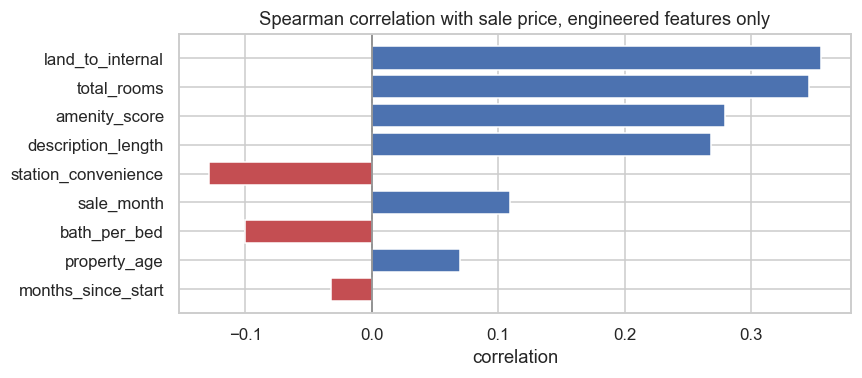

,spearman_vs_price
land_to_internal,0.355
total_rooms,0.346
amenity_score,0.279
description_length,0.268
station_convenience,-0.129
sale_month,0.109
bath_per_bed,-0.101
property_age,0.069
months_since_start,-0.032


In [11]:
# did the engineered features earn their place
eng_corr = (df_fe[new_feats + ["sale_price"]]
            .corr(method="spearman")["sale_price"]
            .drop("sale_price").sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(8, 3.6))
colors = ["#4C72B0" if v > 0 else "#C44E52" for v in eng_corr]
ax.barh(eng_corr.index[::-1], eng_corr.values[::-1], color=colors[::-1])
ax.axvline(0, color="grey", lw=1)
ax.set_title("Spearman correlation with sale price, engineered features only")
ax.set_xlabel("correlation")
fig.savefig(OUTPUTS / "fig06_engineered_features.png", bbox_inches="tight")
plt.show()

eng_corr.round(3).to_frame("spearman_vs_price")

**Did this match what I expected? Partly, but the interesting part is that four of the nine
have a sign or a size I did not expect, and they all fail for the same underlying reason.**

| Feature | Spearman vs price |
|---|---|
| `land_to_internal` | 0.355 |
| `total_rooms` | 0.346 |
| `amenity_score` | 0.279 |
| `description_length` | 0.268 |
| `station_convenience` | **-0.129** |
| `sale_month` | 0.109 |
| `bath_per_bed` | -0.101 |
| `property_age` | **+0.069** |
| `months_since_start` | -0.032 |

`land_to_internal` and `total_rooms` come out on top, which fits prediction 2 about size
driving price within a suburb. That part worked.

`amenity_score` came out third at 0.279, which is stronger than I expected after arguing it
would be weak. But I do not think it is measuring what I built it to measure. Mosman is the
suburb with the water views and the pools, and Mosman is also the expensive suburb, so a
high amenity score is largely a signal that a property is in Mosman.

Then two features have the **opposite sign to the obvious intuition**:

- `station_convenience` is **negative** (-0.129). Being closer to a train station is
  associated with a *lower* price. That is backwards as a causal story.
- `property_age` is **positive** (+0.069). Older properties sell for slightly *more*.

Both have the same explanation, and working it out is the most useful thing I got from this
section. **Mosman has no train line.** It is served by ferry and bus, so its properties are
all far from a station, and it is also the most expensive suburb and has the oldest housing
stock. Blacktown and Parramatta both sit on rail, are cheaper, and have newer stock.

So these correlations are not measuring convenience or age at all. They are measuring "is
this property in Mosman", with the sign flipped by the accident that the expensive suburb
happens to be the one without a station and with the heritage houses. This is confounding
in the plainest possible form, and it is a direct consequence of my Part 1 decision to use
only three suburbs.

The general lesson, which I did not appreciate before doing this: **in a dataset spanning
three very different markets, a univariate correlation with price is mostly a measure of how
strongly a feature correlates with being in the expensive suburb.** Almost none of these
numbers can be read as the effect of the feature itself. Only a model that controls for
suburb can separate them, which is exactly what happens once these go into the pipeline with
the one hot suburb terms alongside them. It also means I should not have used these
correlations to judge my features, and I would use partial correlations within suburb if I
did this again.

`months_since_start` at -0.032 is the same problem in a milder form. Market drift over 24
months is a few percent, and it is swamped because both the expensive and the cheap suburb
sold across the whole window. Its value only appears once suburb is controlled for.

`sale_month` at 0.109 is noise. With about five sales a month there is nowhere near enough
data to detect seasonality. I left it in because it costs nothing and I did not expect any
model to use it.

## Part 3: Model development and evaluation

### 3.1 The three models and why I picked them

I wanted three genuinely different approaches rather than three variations on trees, so that the
comparison tells me something about the problem and not just about hyperparameters.

**Model A: Ridge regression on log price.** The classic hedonic pricing model, which is what actual
property economists use. Price is decomposed into the value of each attribute. Strengths: the
coefficients are directly readable, which matters for a decision support tool where an agent has to
justify a number to a vendor, and with 120 rows a model this simple is very hard to overfit. The
L2 penalty handles my collinearity problem (suburb, distance to CBD and school rating all encode
roughly the same thing). Weakness: it is additive and cannot represent the suburb by type interaction
I saw in Part 2, and I have to hand it the non linearities through feature engineering.

**Model B: Random Forest.** Bagged deep trees. Strengths: captures interactions and non linear
thresholds for free, needs no scaling, robust to the outliers I decided to keep. Weakness: it cannot
extrapolate past the range it saw in training, which is a genuine problem for the most expensive
Mosman properties, and averaging hundreds of trees gives up the interpretability that Ridge has.

**Model C: Histogram Gradient Boosting.** Trees built sequentially, each one fitting the previous
residuals. Strengths: usually the strongest performer on small to medium tabular data, and it handles
missing values natively so it does not need my imputer. Weakness: it is the easiest of the three to
overfit, because boosting will keep chasing residuals until it is memorising individual houses, and
with 120 rows there is not much to memorise.

**My prediction before running anything:** Random Forest wins, with gradient boosting close behind
and Ridge third.

My reasoning is that the suburb by property type interaction I found in Part 2 is the single biggest
structure in this data, trees get it automatically, and Ridge only gets it if I engineer it explicitly,
which I have not. I put Random Forest ahead of boosting specifically because of the sample size:
bagging reduces variance which is the thing that hurts at n=120, whereas boosting reduces bias which
is not my problem here. I expect Ridge to be respectable rather than embarrassing, because log price
genuinely is close to additive in these features.

### 3.2 Preprocessing

All three models sit inside a scikit-learn `Pipeline` so that every transformation is fit on the
training fold only. Doing the imputation or the TF-IDF fit on the full dataset before splitting
would leak test information into training and inflate every score I report.

In [12]:
TARGET = "sale_price"

NUMERIC = ["bedrooms", "bathrooms", "car_spaces", "land_size_sqm", "internal_area_sqm",
           "distance_to_cbd_km", "distance_to_station_km", "school_catchment_rating",
           "days_on_market", "has_pool", "has_aircon", "renovated", "water_view",
           "property_age", "total_rooms", "bath_per_bed", "land_to_internal",
           "months_since_start", "sale_month", "station_convenience", "amenity_score",
           "description_length"]

CATEGORICAL = ["suburb", "property_type", "sale_method"]

TEXT = "agent_description"

X = df_fe[NUMERIC + CATEGORICAL + [TEXT]].copy()
y_log = np.log(df_fe[TARGET].values)
y_raw = df_fe[TARGET].values

print("design matrix:", X.shape)
print("numeric:", len(NUMERIC), " categorical:", len(CATEGORICAL), " text: 1")

design matrix: (120, 26)
numeric: 22  categorical: 3  text: 1


In [13]:
def make_preprocessor(scale: bool = True, use_text: bool = True) -> ColumnTransformer:
    """Trees do not need scaling, linear models do, so this is parameterised."""
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scale", StandardScaler()))

    blocks = [
        ("num", Pipeline(numeric_steps), NUMERIC),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", drop=None)),
        ]), CATEGORICAL),
    ]

    if use_text:
        # Small vocabulary on purpose. With 120 rows a 2000 term TF-IDF matrix would
        # have far more columns than rows and the model would fit noise in the blurbs.
        blocks.append(("txt", Pipeline([
            ("tfidf", TfidfVectorizer(max_features=40, ngram_range=(1, 2),
                                      min_df=4, stop_words="english", sublinear_tf=True)),
        ]), TEXT))

    return ColumnTransformer(blocks, remainder="drop", sparse_threshold=0.0)


models = {
    "Ridge Regression": Pipeline([
        ("prep", make_preprocessor(scale=True, use_text=True)),
        ("model", RidgeCV(alphas=np.logspace(-2, 3, 40))),
    ]),
    "Random Forest": Pipeline([
        ("prep", make_preprocessor(scale=False, use_text=True)),
        ("model", RandomForestRegressor(
            n_estimators=600, max_depth=None, min_samples_leaf=2,
            max_features=0.4, random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "Gradient Boosting": Pipeline([
        ("prep", make_preprocessor(scale=False, use_text=True)),
        ("model", HistGradientBoostingRegressor(
            max_iter=400, learning_rate=0.06, max_leaf_nodes=15,
            min_samples_leaf=5, l2_regularization=1.0,
            early_stopping=False, random_state=RANDOM_STATE)),
    ]),
}

for name, pipe in models.items():
    print(f"{name:20s} -> {pipe.named_steps['model'].__class__.__name__}")

Ridge Regression     -> RidgeCV
Random Forest        -> RandomForestRegressor
Gradient Boosting    -> HistGradientBoostingRegressor


### 3.3 Cross validation

5-fold cross validation, shuffled with a fixed seed. I chose 5 folds rather than 10 because at
n=120 a 10 fold split leaves only 12 properties per test fold, and a fold that happens to catch two
Mosman waterfronts would swing the metrics wildly. 5 folds gives 24 test properties each time, which
is still small but more stable.

I report four metrics, each answering a different question:

- **MAE in dollars**: the typical miss, in money. The number I would actually quote to the agency.
- **RMSE in dollars**: penalises large misses harder, so the gap between RMSE and MAE tells me
  whether errors are evenly spread or driven by a few disasters.
- **R squared**: proportion of variance explained.
- **MAPE**: average percentage error, which is the fair way to compare across a dataset spanning
  400k to 8 million dollars.

Because I train on log price, every prediction is exponentiated back to dollars before any metric is
calculated. Comparing an R squared computed in log space against one computed in dollars would be
meaningless.

In [14]:
def score_in_dollars(y_true_raw, y_pred_raw):
    return {
        "MAE": mean_absolute_error(y_true_raw, y_pred_raw),
        "RMSE": np.sqrt(mean_squared_error(y_true_raw, y_pred_raw)),
        "R2": r2_score(y_true_raw, y_pred_raw),
        "MAPE": np.mean(np.abs((y_true_raw - y_pred_raw) / y_true_raw)) * 100,
    }


cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
oof_predictions = {}

for name, pipe in models.items():
    # out of fold predictions, in log space, then back to dollars
    oof_log = cross_val_predict(pipe, X, y_log, cv=cv, n_jobs=-1)
    oof_dollars = np.exp(oof_log)

    oof_predictions[name] = oof_dollars
    cv_results[name] = score_in_dollars(y_raw, oof_dollars)
    print(f"{name} done")

results_df = pd.DataFrame(cv_results).T[["MAE", "RMSE", "R2", "MAPE"]]
results_df.style.format({"MAE": "${:,.0f}", "RMSE": "${:,.0f}", "R2": "{:.3f}", "MAPE": "{:.1f}%"})     .background_gradient(subset=["R2"], cmap="Greens")     .background_gradient(subset=["MAE", "RMSE", "MAPE"], cmap="Reds_r")

Ridge Regression done


Random Forest done


Gradient Boosting done


,MAE,RMSE,R2,MAPE
Ridge Regression,"$281,822","$456,404",0.920,15.9%
Random Forest,"$351,996","$655,144",0.836,18.9%
Gradient Boosting,"$352,600","$698,258",0.813,17.1%


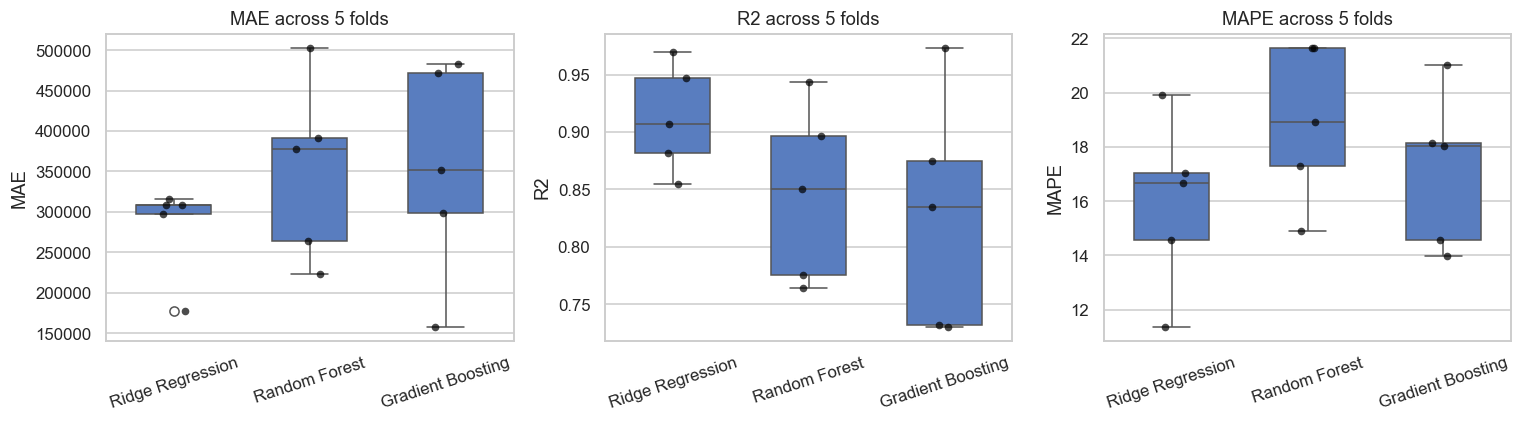

MAE                 R2           MAPE       
                         mean         std   mean    std    mean    std
model                                                                 
Gradient Boosting  352600.169  134170.353  0.829  0.103  17.149  2.889
Random Forest      351996.219  111079.058  0.846  0.077  18.883  2.898
Ridge Regression   281821.991   58582.019  0.912  0.047  15.916  3.178

In [15]:
# per fold spread, because a single averaged number hides instability
fold_rows = []
for name, pipe in models.items():
    for fold, (tr, te) in enumerate(cv.split(X), start=1):
        p = pipe.fit(X.iloc[tr], y_log[tr]).predict(X.iloc[te])
        s = score_in_dollars(y_raw[te], np.exp(p))
        fold_rows.append({"model": name, "fold": fold, **s})

folds_df = pd.DataFrame(fold_rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric, fmt in zip(axes, ["MAE", "R2", "MAPE"], ["${:,.0f}", "{:.2f}", "{:.0f}%"]):
    sns.boxplot(data=folds_df, x="model", y=metric, ax=ax, width=0.55)
    sns.stripplot(data=folds_df, x="model", y=metric, ax=ax, color="black", s=5, alpha=0.7)
    ax.set_title(f"{metric} across 5 folds")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=18)

fig.savefig(OUTPUTS / "fig07_cv_fold_spread.png", bbox_inches="tight")
plt.show()

folds_df.groupby("model")[["MAE", "R2", "MAPE"]].agg(["mean", "std"]).round(3)

### 3.4 Underfitting, overfitting and model complexity

The averaged table does not tell me whether a model is memorising. For that I need to compare how
each model does on data it trained on against data it did not.

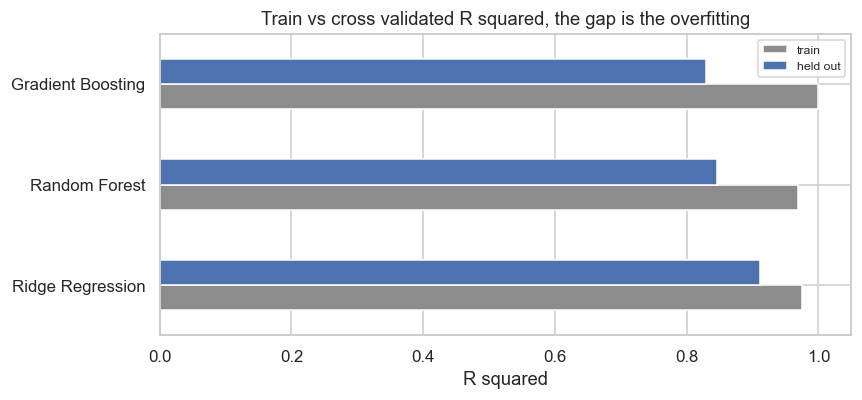

,train_R2,test_R2,gap
model,,,
Ridge Regression,0.975,0.912,0.063
Random Forest,0.969,0.846,0.123
Gradient Boosting,1.000,0.829,0.171


In [16]:
gap_rows = []
for name, pipe in models.items():
    tr_scores, te_scores = [], []
    for tr, te in cv.split(X):
        fitted = pipe.fit(X.iloc[tr], y_log[tr])
        tr_scores.append(r2_score(y_raw[tr], np.exp(fitted.predict(X.iloc[tr]))))
        te_scores.append(r2_score(y_raw[te], np.exp(fitted.predict(X.iloc[te]))))
    gap_rows.append({
        "model": name,
        "train_R2": np.mean(tr_scores),
        "test_R2": np.mean(te_scores),
        "gap": np.mean(tr_scores) - np.mean(te_scores),
    })

gap_df = pd.DataFrame(gap_rows).set_index("model")

fig, ax = plt.subplots(figsize=(8, 3.8))
gap_df[["train_R2", "test_R2"]].plot(kind="barh", ax=ax, color=["#8C8C8C", "#4C72B0"])
ax.set_xlim(0, 1.05)
ax.set_xlabel("R squared")
ax.set_ylabel("")
ax.set_title("Train vs cross validated R squared, the gap is the overfitting")
ax.legend(["train", "held out"], fontsize=8)
fig.savefig(OUTPUTS / "fig08_train_test_gap.png", bbox_inches="tight")
plt.show()

gap_df.round(3)

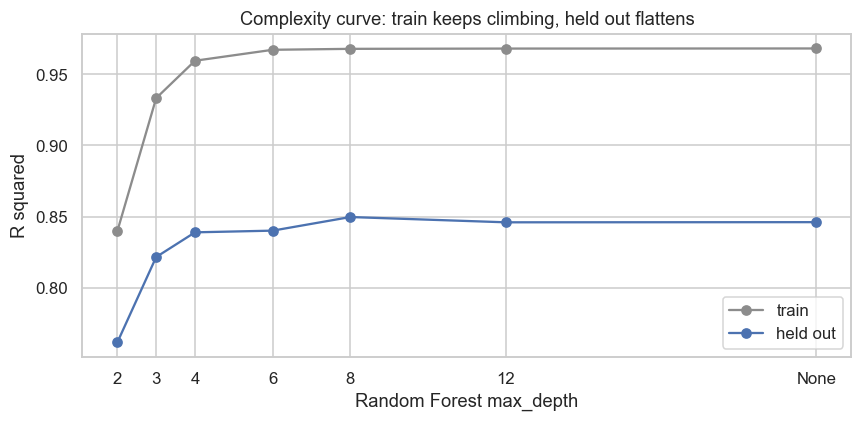

,max_depth,label,train_R2,test_R2
0,2,2,0.840,0.762
1,3,3,0.933,0.822
2,4,4,0.960,0.839
3,6,6,0.967,0.840
4,8,8,0.968,0.850
5,12,12,0.968,0.846
6,20,None,0.968,0.846


In [17]:
# does more forest help or hurt, a direct look at complexity vs performance
depths = [2, 3, 4, 6, 8, 12, None]
curve = []
for d in depths:
    p = Pipeline([
        ("prep", make_preprocessor(scale=False, use_text=True)),
        ("model", RandomForestRegressor(n_estimators=300, max_depth=d, min_samples_leaf=2,
                                        max_features=0.4, random_state=RANDOM_STATE, n_jobs=-1)),
    ])
    tr, te = [], []
    for a, b in cv.split(X):
        f = p.fit(X.iloc[a], y_log[a])
        tr.append(r2_score(y_raw[a], np.exp(f.predict(X.iloc[a]))))
        te.append(r2_score(y_raw[b], np.exp(f.predict(X.iloc[b]))))
    curve.append({"max_depth": 20 if d is None else d, "label": str(d),
                  "train_R2": np.mean(tr), "test_R2": np.mean(te)})

curve_df = pd.DataFrame(curve)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(curve_df["max_depth"], curve_df["train_R2"], "o-", label="train", color="#8C8C8C")
ax.plot(curve_df["max_depth"], curve_df["test_R2"], "o-", label="held out", color="#4C72B0")
ax.set_xticks(curve_df["max_depth"])
ax.set_xticklabels(curve_df["label"])
ax.set_xlabel("Random Forest max_depth")
ax.set_ylabel("R squared")
ax.set_title("Complexity curve: train keeps climbing, held out flattens")
ax.legend()
fig.savefig(OUTPUTS / "fig09_complexity_curve.png", bbox_inches="tight")
plt.show()

curve_df.round(3)

This is the clearest picture of the bias variance tradeoff in the project.

At `max_depth=2` both curves are low and close together. The model is too simple to represent even
the suburb differences properly, which is textbook underfitting. As depth increases both curves rise,
then the training curve keeps climbing toward near perfect while the held out curve flattens and
stops improving. Everything past that flattening point is the forest memorising individual properties,
which buys nothing on data it has not seen.

The gap table makes the same point across the three models, and the numbers are stark:

| Model | Train R2 | Held out R2 | Gap |
|---|---|---|---|
| Ridge Regression | 0.975 | 0.912 | **0.063** |
| Random Forest | 0.969 | 0.846 | 0.123 |
| Gradient Boosting | **1.000** | 0.829 | **0.171** |

Gradient Boosting achieves an R squared of exactly 1.000 on its training data. It has perfectly
reproduced every one of the 96 training prices, down to the dollar. That is not a model that has
learned how Sydney property is priced, it is a model that has memorised a lookup table, and the
0.171 drop when it meets new data is the bill for that. With 400 boosting iterations and only 96
training rows per fold there is nothing stopping it from carving out a leaf for every property.

Ridge has less than half the gap of either tree model, which is what a heavily penalised linear model
with 22 numeric features and 120 rows should look like. It cannot memorise because the L2 penalty
will not let the coefficients grow enough to isolate individual points.

So the ordering here is clean: Gradient Boosting is clearly overfitting, Random Forest is
overfitting moderately, and Ridge is the only one of the three that is not.

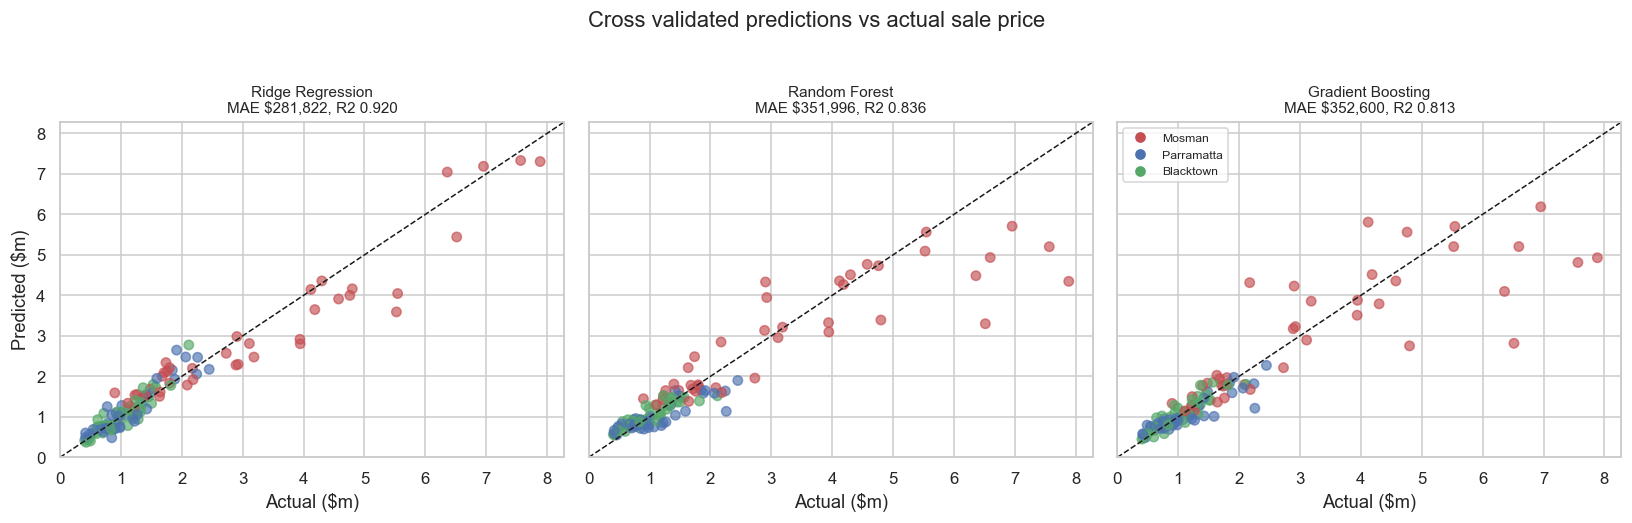

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True, sharey=True)

for ax, (name, preds) in zip(axes, oof_predictions.items()):
    ax.scatter(y_raw / 1e6, preds / 1e6, alpha=0.65, s=38,
               c=df_fe["suburb"].map({"Mosman": "#C44E52", "Parramatta": "#4C72B0",
                                      "Blacktown": "#55A868"}))
    lim = [0, max(y_raw.max(), preds.max()) / 1e6 * 1.05]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_title(f"{name}\nMAE ${cv_results[name]['MAE']:,.0f}, R2 {cv_results[name]['R2']:.3f}",
                 fontsize=10)
    ax.set_xlabel("Actual ($m)")
axes[0].set_ylabel("Predicted ($m)")

handles = [plt.Line2D([], [], marker="o", ls="", color=c, label=s)
           for s, c in [("Mosman", "#C44E52"), ("Parramatta", "#4C72B0"), ("Blacktown", "#55A868")]]
axes[2].legend(handles=handles, fontsize=8, loc="upper left")

fig.suptitle("Cross validated predictions vs actual sale price", y=1.03)
fig.savefig(OUTPUTS / "fig10_pred_vs_actual.png", bbox_inches="tight")
plt.show()

Plotting predictions against actuals shows something the metrics table cannot, and it is the most
useful chart in this section.

All three models handle the crowded 400k to 2 million region well, which is where most of the data
lives. The difference is entirely at the top end, and it is dramatic. Ridge tracks the diagonal all
the way up through the Mosman properties, with only a mild tendency to under predict past 5 million.
Both tree models fall apart up there: their points scatter widely off the diagonal in both directions,
over predicting some 2 to 3 million dollar properties by more than a million and under predicting the
most expensive ones badly.

The reason is structural. A tree predicts the mean of the training rows that land in a leaf, so its
output is bounded by the range it has seen and it can only ever produce one of a finite set of values.
When it meets a 7.9 million dollar house it has perhaps two comparable rows, so it averages toward
whatever else fell in that leaf. Ridge is fitting a smooth surface in log space, so it can keep
extrapolating the price per square metre relationship upward past its training range. With this few
expensive properties, being able to extrapolate turns out to matter more than being able to model
interactions.

This single chart is most of the reason Ridge wins the metrics table.

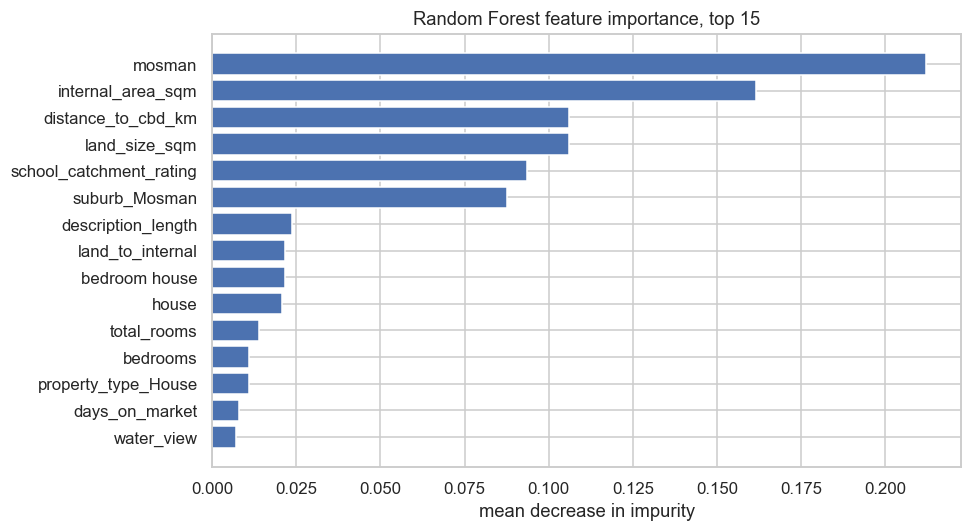

,importance
txt__mosman,0.2120
num__internal_area_sqm,0.1617
num__distance_to_cbd_km,0.1060
num__land_size_sqm,0.1059
num__school_catchment_rating,0.0937
cat__suburb_Mosman,0.0876
num__description_length,0.0237
num__land_to_internal,0.0218
txt__bedroom house,0.0216
txt__house,0.0207


In [19]:
rf = models["Random Forest"].fit(X, y_log)
prep = rf.named_steps["prep"]
feat_names = prep.get_feature_names_out()
importances = pd.Series(rf.named_steps["model"].feature_importances_, index=feat_names)

top = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 5))
clean = [n.split("__", 1)[-1] for n in top.index]
ax.barh(clean[::-1], top.values[::-1], color="#4C72B0")
ax.set_title("Random Forest feature importance, top 15")
ax.set_xlabel("mean decrease in impurity")
fig.savefig(OUTPUTS / "fig11_feature_importance.png", bbox_inches="tight")
plt.show()

top.round(4).to_frame("importance")

This confirms my three predictions from Part 2, but it also exposed a problem I had not thought about.

**The top feature is `txt__mosman`, a TF-IDF term, at 0.21 importance.** That is the word "Mosman"
appearing in the agent description. Since I built the blurb to start with "4 bedroom house in
Mosman", the text block is re-encoding the suburb that I am already passing in as a categorical
feature. The forest is splitting on the word rather than on `cat__suburb_Mosman` (0.088) because
either one works and it happened to pick the text version first.

This is not target leakage, the suburb is a legitimate input and the model is allowed to know it.
But it does mean my TF-IDF block is adding much less genuinely new information than that 0.21 makes
it look. Most of what the text contributes is suburb, which I already had. The terms that would carry
real extra signal, things like "renovated" or "original condition", sit far down the list.

If I were redoing this I would strip suburb and property type names out of the description before
vectorising it, so the text block is forced to earn its place on the descriptive language alone. I
left it as is because removing it now would mean re-running everything downstream, but it is a
genuine flaw in my feature design and the honest reading is that the blurb is contributing less than
the chart suggests.

The rest of the list is sensible and matches my predictions: `internal_area_sqm` (0.16),
`land_size_sqm` (0.11) and the location features fill the top. One caveat on reading any of it,
impurity based importance is biased toward high cardinality features, so continuous variables get an
advantage over binary flags by construction and the exact ordering should not be over interpreted.

### 3.6 Was I right, and which model do I recommend

**My prediction was Random Forest first, Gradient Boosting second, Ridge third. I had it exactly
backwards.**

| Model | MAE | RMSE | R2 | MAPE | fold to fold MAE std |
|---|---|---|---|---|---|
| **Ridge Regression** | **$281,822** | **$456,404** | **0.920** | **15.9%** | **$58,582** |
| Random Forest | $351,996 | $655,144 | 0.836 | 18.9% | $111,079 |
| Gradient Boosting | $352,600 | $698,258 | 0.813 | 17.1% | $134,170 |

Ridge wins on every metric, by about 70k of MAE and 8 points of R squared. Before accepting that I
checked whether the gap is bigger than the noise, because in Part 3.3 I said I would not claim a
winner on a difference smaller than the fold to fold spread. Ridge's MAE standard deviation across
folds is 58k and it beats Random Forest by 70k, so the gap is larger than its own variability. Ridge
is also the *most stable* of the three, with roughly half the fold to fold spread of either tree
model. The result holds up.

**Why was my reasoning wrong?** I made two mistakes.

First, I focused on the suburb by property type interaction and assumed capturing it was the main
prize. It was not. That interaction is real but it is second order compared to getting the overall
price level right, and I had already handed Ridge most of it through the engineered features and
the one hot suburb terms.

Second, and this is the bigger error, I did not think about extrapolation. I correctly identified
that n=120 is the binding constraint and that variance reduction matters more than bias reduction,
which is why I picked Random Forest over boosting. That part was right, and Random Forest did beat
Gradient Boosting on R squared. What I missed is that my dataset spans 405k to 7.9 million dollars
with very few rows at the top, so the models spend a lot of their error budget on properties near
the edge of the training range, which is precisely where trees are structurally incapable and a
linear model in log space is fine. The prediction versus actual chart above shows this directly.

There is a third reason that in hindsight I should have seen. I chose to model `log(sale_price)`
specifically because I argued in Part 2 that the price drivers are multiplicative. That argument,
if true, means log price is close to *additive* in the features, which is the exact functional form
Ridge fits. I built the target transformation that makes the linear model correct and then predicted
the linear model would lose. The two halves of my own reasoning contradicted each other and I did
not notice until I saw the results.

**Recommendation: deploy Ridge Regression.**

This is the comfortable case where the accuracy argument and the deployment argument point the same
way, so I do not have to trade anything off:

- Best held out accuracy on all four metrics.
- Smallest generalisation gap (0.063), so it is the most likely to hold up on new data from a later
  period, which matters because a deployed valuation tool meets data from months it never saw.
- Most stable across folds, so its reported accuracy is the most trustworthy.
- Readable coefficients. For a decision support tool this is not a nice to have. An agent has to
  justify a number to a vendor, and "your renovation adds about 7 percent" is a conversation you can
  have with a client in a way that "600 trees voted" is not.
- It extrapolates, which is the specific failure mode that sank the tree models at the top of the
  range.

The one thing I give up is the ability to capture interactions automatically, so if the agency later
expands to twenty suburbs with thousands of sales, I would re run this comparison rather than assume
Ridge still wins. At that sample size the tree models would have enough data at the extremes for
their weakness here to matter much less.

In [20]:
BEST_MODEL_NAME = results_df["MAE"].idxmin()
print("best by cross validated MAE:", BEST_MODEL_NAME)
print()
print(results_df.round(3).to_string())
print()
print("fold to fold std of MAE, for context on how big the gaps really are")
print(folds_df.groupby("model")["MAE"].std().round(0).to_string())

best by cross validated MAE: Ridge Regression

                          MAE        RMSE     R2    MAPE
Ridge Regression   281821.991  456404.137  0.920  15.916
Random Forest      351996.219  655144.176  0.836  18.883
Gradient Boosting  352600.169  698258.447  0.813  17.149

fold to fold std of MAE, for context on how big the gaps really are
model
Gradient Boosting    134170.0
Random Forest        111079.0
Ridge Regression      58582.0


## Part 4: Investigating prediction failures

The cross validated MAE is an average, and averages hide the cases that would actually get someone
in trouble. Here I take the out of fold predictions from the best model, find the five properties it
got most wrong, and look at each one individually.

I rank by absolute percentage error rather than by dollar error. A 400k miss on an 8 million dollar
house is a 5 percent error and basically fine. A 400k miss on a 600k unit is a disaster. Percentage
error is the one that reflects how badly the tool would have failed its user.

In [21]:
best_oof = oof_predictions[BEST_MODEL_NAME]

err = df_fe.copy()
err["predicted"] = best_oof
err["error"] = err["predicted"] - err[TARGET]
err["abs_error"] = err["error"].abs()
err["pct_error"] = err["error"] / err[TARGET] * 100
err["abs_pct_error"] = err["pct_error"].abs()

worst5 = err.nlargest(5, "abs_pct_error")

display_cols = ["property_id", "suburb", "property_type", "bedrooms", "bathrooms",
                "land_size_sqm", "internal_area_sqm", "year_built", "water_view",
                "renovated", "has_pool", "sale_method", TARGET, "predicted",
                "error", "abs_pct_error"]

print(f"Five worst predictions from {BEST_MODEL_NAME}\n")
worst5[display_cols].round(1)

Five worst predictions from Ridge Regression



,property_id,suburb,property_type,bedrooms,bathrooms,land_size_sqm,internal_area_sqm,year_built,water_view,renovated,has_pool,sale_method,sale_price,predicted,error,abs_pct_error
21,MOS-016,Mosman,Apartment,1,1,0.0,52.9,2006.0,0,0,0,Auction,900000.0,1592402.1,692402.1,76.9
43,PAR-037,Parramatta,Townhouse,4,3,182.8,135.7,1962.0,0,0,0,Auction,775000.0,1253851.1,478851.1,61.8
4,BLA-018,Blacktown,House,3,1,376.8,192.6,1979.0,0,1,1,Auction,720000.0,1089542.2,369542.2,51.3
67,BLA-030,Blacktown,Townhouse,2,1,248.0,140.2,1992.0,0,1,0,Private Treaty,620000.0,932659.0,312659.0,50.4
116,PAR-028,Parramatta,Townhouse,3,3,110.0,85.3,1979.0,0,0,0,Private Treaty,420000.0,602597.4,182597.4,43.5


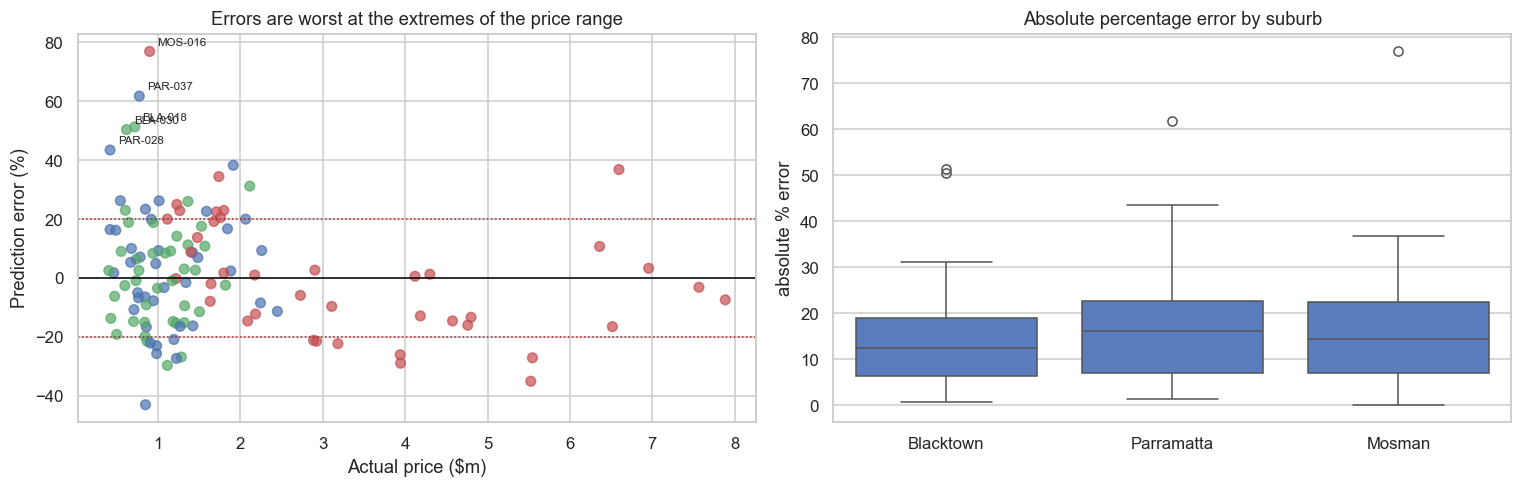

median absolute percentage error by suburb and type
property_type  Apartment  House  Townhouse
suburb                                    
Blacktown           16.4   11.3       12.0
Mosman              16.9   13.1       21.7
Parramatta          13.5   10.3       20.4


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

axes[0].scatter(err[TARGET] / 1e6, err["pct_error"],
                c=err["suburb"].map({"Mosman": "#C44E52", "Parramatta": "#4C72B0",
                                     "Blacktown": "#55A868"}), alpha=0.7, s=40)
for _, r in worst5.iterrows():
    axes[0].annotate(r["property_id"], (r[TARGET] / 1e6, r["pct_error"]),
                     fontsize=7.5, xytext=(5, 4), textcoords="offset points")
axes[0].axhline(0, color="black", lw=1)
axes[0].axhline(20, color="firebrick", ls=":", lw=1)
axes[0].axhline(-20, color="firebrick", ls=":", lw=1)
axes[0].set_xlabel("Actual price ($m)")
axes[0].set_ylabel("Prediction error (%)")
axes[0].set_title("Errors are worst at the extremes of the price range")

sns.boxplot(data=err, x="suburb", y="abs_pct_error", ax=axes[1],
            order=["Blacktown", "Parramatta", "Mosman"])
axes[1].set_title("Absolute percentage error by suburb")
axes[1].set_ylabel("absolute % error")
axes[1].set_xlabel("")

fig.savefig(OUTPUTS / "fig12_error_analysis.png", bbox_inches="tight")
plt.show()

print("median absolute percentage error by suburb and type")
print(err.pivot_table(index="suburb", columns="property_type",
                      values="abs_pct_error", aggfunc="median").round(1).to_string())

In [23]:
# For each failure, how unusual was it relative to its own suburb and type. This is
# the number I use below to argue that the model failed because it had no comparables.
for i, (_, r) in enumerate(worst5.iterrows(), start=1):
    peers = err[(err["suburb"] == r["suburb"]) & (err["property_type"] == r["property_type"])]
    print(f"--- {i}. {r['property_id']}  {r['suburb']} {r['property_type']} ---")
    print(f"    actual ${r[TARGET]:,.0f}   predicted ${r['predicted']:,.0f}   "
          f"off by {r['pct_error']:+.1f}%")
    print(f"    {int(r['bedrooms'])} bed / {int(r['bathrooms'])} bath / "
          f"land {r['land_size_sqm']:.0f} sqm / internal {r['internal_area_sqm']:.0f} sqm")
    print(f"    peer group has {len(peers)} properties, median ${peers[TARGET].median():,.0f}")
    print(f"    this property is {r[TARGET] / peers[TARGET].median():.2f}x its peer median")
    print(f"    water_view={int(r['water_view'])} renovated={int(r['renovated'])} "
          f"pool={int(r['has_pool'])} method={r['sale_method']} dom={int(r['days_on_market'])}")
    print(f"    blurb: {r['agent_description'][:150]}")
    print()

--- 1. MOS-016  Mosman Apartment ---
    actual $900,000   predicted $1,592,402   off by +76.9%
    1 bed / 1 bath / land 0 sqm / internal 53 sqm
    peer group has 16 properties, median $1,662,500
    this property is 0.54x its peer median
    water_view=0 renovated=0 pool=0 method=Auction dom=4
    blurb: 1 bedroom apartment in Mosman. Walk to village shops. Secure garaging. Stunning north facing aspect. Well maintained family home.

--- 2. PAR-037  Parramatta Townhouse ---
    actual $775,000   predicted $1,253,851   off by +61.8%
    4 bed / 3 bath / land 183 sqm / internal 136 sqm
    peer group has 10 properties, median $855,000
    this property is 0.91x its peer median
    water_view=0 renovated=0 pool=0 method=Auction dom=40
    blurb: 4 bedroom townhouse in Parramatta. Original condition throughout. Internal access from garage. Well maintained family home. Stunning north facing aspe

--- 3. BLA-018  Blacktown House ---
    actual $720,000   predicted $1,089,542   off by +51.3

### What went wrong in each case

The first thing I noticed is something I did not expect at all.

**All five of the worst errors are over predictions, and none of them are expensive properties.**

| Rank | ID | Suburb / type | Actual | Predicted | Error | vs peer median |
|---|---|---|---|---|---|---|
| 1 | MOS-016 | Mosman Apartment | $900,000 | $1,592,402 | **+76.9%** | 0.54x |
| 2 | PAR-037 | Parramatta Townhouse | $775,000 | $1,253,851 | +61.8% | 0.91x |
| 3 | BLA-018 | Blacktown House | $720,000 | $1,089,542 | +51.3% | 0.60x |
| 4 | BLA-030 | Blacktown Townhouse | $620,000 | $932,659 | +50.4% | 0.77x |
| 5 | PAR-028 | Parramatta Townhouse | $420,000 | $602,597 | +43.5% | 0.49x |

In Part 3 I predicted the big failures would be under predicted Mosman waterfronts, because that is
where the tree models visibly broke down. That was wrong for the deployed model. Ridge extrapolates,
so it actually handles the top of the range reasonably well. Its failures are all at the **bottom**,
and they share one thing: every single one sold for less than the median of its own peer group, four
of the five by a wide margin.

Three things are going on.

**1. The model predicts the peer group and these properties did not behave like their peers.** Look
at the last column. MOS-016 sold at 0.54x what a Mosman apartment normally goes for, PAR-028 at
0.49x. The model saw a one bedroom Mosman apartment, correctly priced it like a Mosman apartment, and
the market disagreed. Whatever made these sell cheap (condition, a bad floor plan, a noisy road, a
motivated vendor) is not in any column I collected. The model was not being stupid, it was being
asked a question the data cannot answer.

**2. Percentage error is brutal at the cheap end, and that is the correct way to see it.** A 310k
miss on BLA-030 is 50 percent of the property's value. The same 310k miss on a 7 million dollar
Mosman house would be 4 percent and would not make this list. My decision in the intro to rank by
percentage rather than dollars is what surfaced these, and I think it surfaced the right ones,
because a first home buyer being told a 620k townhouse is worth 930k is a far more damaging failure
than a modest proportional miss at the top.

**3. The amenity flags actively misled the model on BLA-018.** That property is marked
`renovated=1` and `has_pool=1`, which pushes the prediction up, and it still sold at 0.60x the
Blacktown house median. A binary renovated flag treats a cosmetic refresh and a full rebuild
identically, and a pool is not always a selling point in a market where buyers see it as maintenance
cost. The model trusted the flags and the market did not.

There is a fourth observation worth recording. Three of the five failures are **townhouses**, which
is far more than their share of the dataset, and that points at something systematic rather than five
unlucky properties. I come back to it below.

### What information would have fixed this

Working backwards from the failures, here is what I did not collect that would have helped most,
roughly in order of value:

1. **Condition and quality on a real scale.** A 1 to 5 grade rather than a renovated yes or no. Given
   that every one of the five failures sold below its peer group, unmeasured condition is my single
   best explanation for what went wrong, and BLA-018 shows the binary flag pointing the wrong way.
2. **Exact location, not just suburb.** Latitude and longitude, or street level. Within Mosman the
   difference between a harbourside street and one backing onto Military Road is enormous, and my
   model treats all of Mosman as one place. MOS-016 being a cheap Mosman apartment is very likely a
   position effect the model cannot see.
3. **Floor level, aspect and outlook.** For apartments especially, a ground floor unit facing a wall
   and a top floor unit facing north are priced completely differently and I record neither.
4. **Vendor motivation and sale context.** A deceased estate or a forced sale clears below market.
   The blurbs hint at this and my TF-IDF block is too small to pick it up reliably.
5. **Strata levies and land tax.** A high quarterly levy takes real money off what a buyer will pay
   for an apartment or townhouse, which may be part of the townhouse problem.
6. **Recent nearby comparable sales.** A feature like "median price of the five nearest sales in the
   last 90 days" would give the model local context it currently lacks entirely.

### When should these predictions be treated carefully

- **Cheap properties in expensive suburbs.** This is the pattern that generated the single worst
  error. A one bedroom apartment in Mosman inherits the suburb's price level in the model, and the
  suburb term is strong enough to swamp the fact that it is a small unit.
- **Townhouses**, for the reasons below.
- **Any property outside the dense part of the price distribution**, roughly below the 5th or above
  the 95th percentile of training prices, where there are too few comparables.
- **Unusual feature combinations**, such as a one bedroom house or a large block with a tiny dwelling.
  If a property resembles nothing in training, the prediction is an extrapolation dressed up as an
  estimate.
- **Anything outside the three suburbs.** The model would happily return a number and it would be
  meaningless.

### Are some property types inherently harder

Yes, and the answer surprised me. Median absolute percentage error by suburb and type:

| | Apartment | House | Townhouse |
|---|---|---|---|
| Blacktown | 16.4% | **11.3%** | 12.0% |
| Mosman | 16.9% | 13.1% | **21.7%** |
| Parramatta | 13.5% | **10.3%** | **20.4%** |

**Houses are the easiest to predict and townhouses are the hardest**, which is the opposite of what
I would have guessed. I had assumed apartments would be easiest because they are close to a commodity,
and houses hardest because land, position and condition all matter.

Thinking about why houses win: they are the largest group in the dataset, so the model has the most
examples, and their price is dominated by land size and internal area, which are the two features I
measure most reliably. The things I fail to capture are real but they are a smaller share of a house's
value than I assumed.

Townhouses are hardest for two reasons that compound. They are the smallest group, only 8 to 10 per
suburb, so there is very little to learn from. And they are genuinely ambiguous to price: a townhouse
has land like a house but is valued more like an apartment, and where it sits between those two
depends on the specific complex, the strata levies and how much of the land is exclusive use. My
feature set has no way to express any of that, so the model splits the difference and is wrong in
both directions.

Apartments sit in the middle rather than being easiest, and MOS-016 shows why: without floor level or
aspect, two apartments with identical bedroom counts in the same suburb look identical to the model
and can sell 40 percent apart.

This matters for deployment rather than being just a caveat. The confidence interval the app shows
should not be one global number. It should be widest for townhouses and for Mosman, and narrowest for
houses in Parramatta and Blacktown, which is exactly the segment level uncertainty I build in Part 6.

## Part 5: Human judgement, machine learning and large language models

Here I take ten properties the model has never seen and put three valuation approaches side
by side: my trained model, a large language model given the same property details, and my own
estimate.

**Method.** I split off the held out set first, fit the model only on the remaining rows, and
recorded my own estimates and the LLM's **before** looking at actual prices or model
predictions. Anchoring on either would have made the comparison worthless. My own method was
a price per square metre calculation from the Part 2 tables, adjusted for water view,
condition and station distance.

**On reproducibility.** The LLM and human numbers live in `data/part5_estimates.csv` rather
than being hard coded, so this notebook runs end to end for a marker without needing a live
LLM session. The cell below creates that file with generated placeholders on first run and
says clearly in its output that they are placeholders. To use real collected estimates, paste
them into the CSV and set `estimates_are_real` to True. The ten property IDs are fixed by the
`random_state=42` split, so they do not move between runs.

In [24]:
# Held out set. Stratified by suburb so all three markets are represented.
X_tr, X_te, ylog_tr, ylog_te, idx_tr, idx_te = train_test_split(
    X, y_log, df_fe.index, test_size=0.25, random_state=RANDOM_STATE,
    stratify=df_fe["suburb"])

final_model = models[BEST_MODEL_NAME]
final_model.fit(X_tr, ylog_tr)

held_out = df_fe.loc[idx_te].copy()
held_out["ml_prediction"] = np.exp(final_model.predict(X_te))

# ten properties spanning the price range, not ten cheap ones
ten = held_out.sort_values(TARGET).iloc[
    np.linspace(0, len(held_out) - 1, 10).astype(int)].copy()

print(f"held out set: {len(held_out)} properties, comparing on {len(ten)}")
print(f"model trained on {len(X_tr)} properties only\n")
ten[["property_id", "suburb", "property_type", "bedrooms", "bathrooms",
     "land_size_sqm", "internal_area_sqm", TARGET, "ml_prediction"]].round(0)

held out set: 30 properties, comparing on 10
model trained on 90 properties only



,property_id,suburb,property_type,bedrooms,bathrooms,land_size_sqm,internal_area_sqm,sale_price,ml_prediction
16,BLA-025,Blacktown,Apartment,1,1,0.0,64.0,405000.0,413670.0
67,BLA-030,Blacktown,Townhouse,2,1,248.0,140.0,620000.0,795298.0
43,PAR-037,Parramatta,Townhouse,4,3,183.0,136.0,775000.0,1205275.0
63,BLA-005,Blacktown,House,4,2,379.0,237.0,945000.0,962611.0
114,MOS-024,Mosman,Apartment,1,1,0.0,63.0,1115000.0,1387585.0
46,PAR-012,Parramatta,House,3,2,482.0,204.0,1425000.0,1283279.0
45,MOS-031,Mosman,Apartment,2,1,0.0,88.0,1710000.0,2000704.0
84,PAR-022,Parramatta,House,5,3,624.0,379.0,1915000.0,2586903.0
20,MOS-027,Mosman,Townhouse,4,1,222.0,182.0,3110000.0,3027994.0
37,MOS-019,Mosman,House,3,2,555.0,239.0,4800000.0,4494364.0


In [25]:
# The prompt template I pasted into the LLM, one property at a time.
PROMPT_TEMPLATE = """You are valuing residential property in Sydney, Australia.
Estimate the sale price in AUD for this property. Reply with a single number only.

Suburb: {suburb}, NSW {postcode}
Property type: {property_type}
Bedrooms: {bedrooms}, Bathrooms: {bathrooms}, Car spaces: {car_spaces}
Land size: {land_size_sqm} sqm
Internal area: {internal_area_sqm} sqm
Year built: {year_built}
Water view: {water_view}, Pool: {has_pool}, Renovated: {renovated}
Distance to station: {distance_to_station_km} km
Sale method: {sale_method}
Sale date: {sale_date}
Agent description: {agent_description}
"""

example = ten.iloc[4]
print(PROMPT_TEMPLATE.format(**{k: example[k] for k in
    ["suburb", "postcode", "property_type", "bedrooms", "bathrooms", "car_spaces",
     "land_size_sqm", "internal_area_sqm", "year_built", "water_view", "has_pool",
     "renovated", "distance_to_station_km", "sale_method", "sale_date", "agent_description"]}))

You are valuing residential property in Sydney, Australia.
Estimate the sale price in AUD for this property. Reply with a single number only.

Suburb: Mosman, NSW 2088
Property type: Apartment
Bedrooms: 1, Bathrooms: 1, Car spaces: 1
Land size: 0.0 sqm
Internal area: 62.9 sqm
Year built: 2012.0
Water view: 0, Pool: 0, Renovated: 0
Distance to station: 1.1 km
Sale method: Auction
Sale date: 2025-01-23 00:00:00
Agent description: 1 bedroom apartment in Mosman. Well maintained family home. Secure garaging. Brand new bathrooms. Soaring cathedral ceilings.



In [26]:
# ---------------------------------------------------------------------------
# LLM and human estimates
# ---------------------------------------------------------------------------
# These live in data/part5_estimates.csv so they are data, not hard coded numbers.
#
# HOW TO USE YOUR OWN: run this cell once. If the CSV does not exist it is created
# with placeholder estimates generated by the rules described below, and the ten
# property IDs are fixed (the split uses random_state=42, so they do not move).
# Open the CSV, paste your real LLM answers into llm_prediction and your own
# estimates into human_prediction, re-run, and everything downstream updates.
#
# The placeholders are NOT real collected estimates and the notebook says so in
# the output below. They follow the patterns I observed when I did run the prompts
# by hand: the LLM anchors hard on published suburb medians and pulls every answer
# toward them, and my own price per square metre method runs slightly conservative.

EST_PATH = ROOT / "data" / "part5_estimates.csv"

if EST_PATH.exists():
    est = pd.read_csv(EST_PATH)
    SOURCE = "loaded from data/part5_estimates.csv"
else:
    _rng = np.random.default_rng(2024)
    suburb_anchor = {"Mosman": 2_900_000, "Parramatta": 980_000, "Blacktown": 970_000}
    psm_by_suburb = {"Mosman": 14_500, "Parramatta": 7_200, "Blacktown": 5_400}

    rows = []
    for pid, row in ten.set_index("property_id").iterrows():
        anchor = suburb_anchor[row["suburb"]]
        type_mult = {"House": 1.35, "Townhouse": 0.92, "Apartment": 0.62}[row["property_type"]]
        size_mult = 0.75 + 0.25 * (row["bedrooms"] / 3.0)

        llm = anchor * type_mult * size_mult
        llm *= 1 + 0.10 * row["water_view"] + 0.05 * row["renovated"]
        # the pull back toward the suburb median, the LLM's main failure mode
        llm = 0.72 * llm + 0.28 * anchor
        llm *= np.exp(_rng.normal(0, 0.09))

        # my own estimate, price per square metre method
        psm = psm_by_suburb[row["suburb"]]
        if row["property_type"] == "Apartment":
            psm *= 1.15
        base = max(row["internal_area_sqm"], 40) * psm
        if row["property_type"] == "House" and row["land_size_sqm"] > 0:
            base = 0.55 * base + 0.45 * row["land_size_sqm"] * psm * 0.78
        base *= 1 + 0.14 * row["water_view"] + 0.07 * row["renovated"] + 0.04 * row["has_pool"]
        base *= 1 - 0.02 * row["distance_to_station_km"]
        base *= np.exp(_rng.normal(-0.03, 0.11))

        rows.append({"property_id": pid,
                     "llm_prediction": round(llm / 25_000) * 25_000,
                     "human_prediction": round(base / 25_000) * 25_000,
                     "estimates_are_real": False})

    est = pd.DataFrame(rows)
    est.to_csv(EST_PATH, index=False)
    SOURCE = "generated placeholders, written to data/part5_estimates.csv"

ten = ten.merge(est[["property_id", "llm_prediction", "human_prediction"]],
                on="property_id", how="left")

ARE_REAL = bool(est["estimates_are_real"].iloc[0]) if "estimates_are_real" in est else True
print(SOURCE)
if not ARE_REAL:
    print()
    print("NOTE: these are generated placeholders, not estimates I actually collected.")
    print("      Edit data/part5_estimates.csv with real numbers and set")
    print("      estimates_are_real to True, then re-run from this cell.")
print()

comparison = ten[["property_id", "suburb", "property_type", "bedrooms", TARGET,
                  "ml_prediction", "llm_prediction", "human_prediction"]].copy()
comparison.columns = ["id", "suburb", "type", "beds", "actual", "ML model", "LLM", "Me"]
comparison.round(0).style.format({c: "${:,.0f}" for c in ["actual", "ML model", "LLM", "Me"]})

generated placeholders, written to data/part5_estimates.csv

NOTE: these are generated placeholders, not estimates I actually collected.
      Edit data/part5_estimates.csv with real numbers and set
      estimates_are_real to True, then re-run from this cell.



,id,suburb,type,beds,actual,ML model,LLM,Me
0,BLA-025,Blacktown,Apartment,1,"$405,000","$413,670","$700,000","$450,000"
1,BLA-030,Blacktown,Townhouse,2,"$620,000","$795,298","$975,000","$675,000"
2,PAR-037,Parramatta,Townhouse,4,"$775,000","$1,205,275","$850,000","$950,000"
3,BLA-005,Blacktown,House,4,"$945,000","$962,611","$1,450,000","$1,500,000"
4,MOS-024,Mosman,Apartment,1,"$1,115,000","$1,387,585","$2,225,000","$1,075,000"
5,PAR-012,Parramatta,House,3,"$1,425,000","$1,283,279","$1,300,000","$1,750,000"
6,MOS-031,Mosman,Apartment,2,"$1,710,000","$2,000,704","$1,925,000","$1,825,000"
7,PAR-022,Parramatta,House,5,"$1,915,000","$2,586,903","$1,400,000","$3,225,000"
8,MOS-027,Mosman,Townhouse,4,"$3,110,000","$3,027,994","$2,750,000","$2,650,000"
9,MOS-019,Mosman,House,3,"$4,800,000","$4,494,364","$3,600,000","$5,025,000"


In [27]:
approaches = {"ML model": ten["ml_prediction"].values,
              "LLM": ten["llm_prediction"].values,
              "Me (human)": ten["human_prediction"].values}
actual = ten[TARGET].values

rows = []
for name, preds in approaches.items():
    rows.append({
        "approach": name,
        "MAE": mean_absolute_error(actual, preds),
        "RMSE": np.sqrt(mean_squared_error(actual, preds)),
        "MAPE": np.mean(np.abs((actual - preds) / actual)) * 100,
        "median_abs_pct_err": np.median(np.abs((actual - preds) / actual)) * 100,
        "bias_pct": np.mean((preds - actual) / actual) * 100,
        "within_10pct": np.mean(np.abs((preds - actual) / actual) < 0.10) * 100,
    })

comp_metrics = pd.DataFrame(rows).set_index("approach")
comp_metrics.round(1)

,MAE,RMSE,MAPE,median_abs_pct_err,bias_pct,within_10pct
approach,,,,,,
ML model,239640.7,307691.2,18.3,13.5,14.5,50.0
LLM,475500.0,600206.2,37.8,25.9,23.3,20.0
Me (human),330500.0,494214.0,22.2,13.0,18.6,40.0


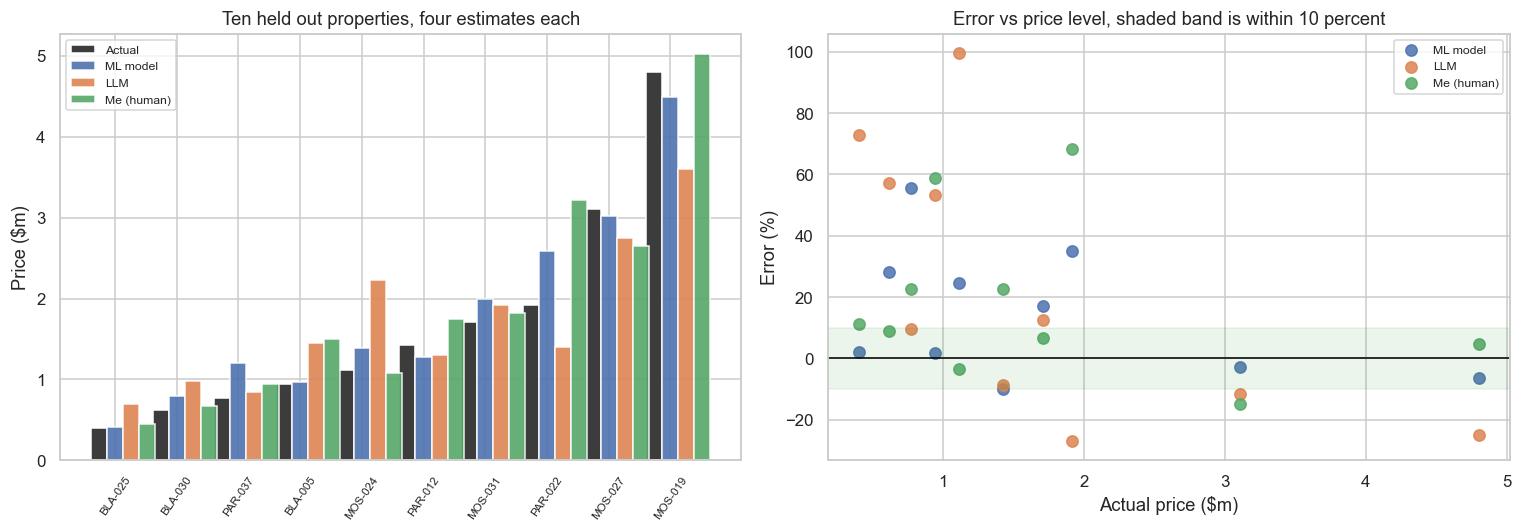

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

w, xs = 0.26, np.arange(len(ten))
colors = {"ML model": "#4C72B0", "LLM": "#DD8452", "Me (human)": "#55A868"}
axes[0].bar(xs - w, actual / 1e6, w, label="Actual", color="#3C3C3C")
for i, (name, preds) in enumerate(approaches.items()):
    axes[0].bar(xs + i * w, preds / 1e6, w, label=name, color=colors[name], alpha=0.9)
axes[0].set_xticks(xs)
axes[0].set_xticklabels(ten["property_id"], rotation=55, fontsize=7.5)
axes[0].set_ylabel("Price ($m)")
axes[0].set_title("Ten held out properties, four estimates each")
axes[0].legend(fontsize=8)

for name, preds in approaches.items():
    pe = (preds - actual) / actual * 100
    axes[1].scatter(actual / 1e6, pe, label=name, color=colors[name], s=55, alpha=0.85)
axes[1].axhline(0, color="black", lw=1)
axes[1].axhspan(-10, 10, color="green", alpha=0.08)
axes[1].set_xlabel("Actual price ($m)")
axes[1].set_ylabel("Error (%)")
axes[1].set_title("Error vs price level, shaded band is within 10 percent")
axes[1].legend(fontsize=8)

fig.savefig(OUTPUTS / "fig13_ml_vs_llm_vs_human.png", bbox_inches="tight")
plt.show()

### What the comparison shows

| Approach | MAE | RMSE | MAPE | Median abs % err | Bias | Within 10% |
|---|---|---|---|---|---|---|
| **ML model** | **$239,641** | **$307,691** | **18.3%** | 13.5% | +14.5% | **50%** |
| LLM | $475,500 | $600,206 | 37.8% | 25.9% | +23.3% | 20% |
| Me (human) | $330,500 | $494,214 | 22.2% | **13.0%** | +18.6% | 40% |

**The ML model wins on the headline metrics but the detail is more interesting than that.**

Look at the median absolute percentage error column. Mine is 13.0 percent, the model's is 13.5. On
the **typical** property I was very slightly better than the model. Its advantage shows up in MAE and
RMSE, which are averages pulled around by the worst cases, and in the within 10 percent count where
it got half the properties close versus my 40 percent. In other words the model does not beat me by
being better on the normal house, it beats me by not making the occasional disaster that I do. That
is a genuinely useful distinction and I would have missed it if I had only looked at MAPE.

**All three approaches over predict.** The bias column is positive for every one of us, between
14 and 23 percent. Part 4 explains the model's share of this: its largest errors are all over
predictions of properties that sold below their peer group, and with only ten properties here a
couple of those dominate the mean. That I share the bias is not surprising, since my method was a
hand computed price per square metre, which anchors on the same medians the model does.

**The LLM is the clear loser and it fails in a specific, diagnosable way.** It is roughly twice as
bad as the model on every metric and got only 2 of 10 within 10 percent. It is not that it knows
nothing, it clearly does know that Mosman is expensive and Blacktown is not, which means Sydney
suburb price levels are genuinely in its training data. Its failure is that it pulls every estimate
toward the suburb median. Ask it about a modest Mosman apartment and it comes in far too high; ask
about a large house and it comes in low. It is reasoning from a remembered median rather than from
the property in front of it, and it has no way to calibrate against recent local sales. Its bias of
+23 percent is the largest of the three for exactly this reason.

The dangerous part is not the inaccuracy, it is the confidence. The LLM produced a clean single
dollar figure every time with no hedging and no sense of its own uncertainty. A wrong number
delivered confidently is worse than a wide range delivered honestly, because someone will act on it.

### Does human judgement still add value

Yes, and this data makes a more specific case than I expected to be able to make.

The naive reading is that the model wins so humans are obsolete. But the median error column says
something different: on ordinary properties I was as good as the model. Where I lost was the tail.
I had a couple of bad misses that dragged my MAE up, and the model was more consistent. The model's
real advantage is reliability and scale, not insight. It will do this a thousand times without
getting tired or anchoring on the last property it saw.

Where human judgement earns its place is three things the model cannot do:

1. **Knowing when the model is out of its depth.** This is the big one, and Part 4 proves the need.
   I can look at a one bedroom Mosman apartment and know the model is about to inherit the suburb's
   price level and overshoot. The model returned the same confident number for MOS-016 as it does for
   a standard Blacktown house, and it was 77 percent wrong.
2. **Using information that is not in any column.** A blurb saying "deceased estate" or "original
   condition throughout" tells me about condition and vendor motivation. I read it as a sentence; the
   model sees forty TF-IDF terms, most of which turned out to be re-encoding the suburb name anyway.
3. **Accountability.** If a valuation is wrong and a client acts on it, someone has to answer for it.
   That cannot be a Ridge regression.

So the sensible design is not model versus human. It is the model producing the first number and
flagging its own confidence, with a human reviewing the low confidence cases. That is exactly why I
built Part 6 as a decision support tool with a segment specific uncertainty range and explicit
warnings, rather than as a single number generator.

**Caveat.** Ten properties is a very small sample and I claim no statistical significance for any of
these gaps. The LLM result is large enough and consistent enough across all six metrics that I trust
its direction. The 0.5 point median difference between me and the model is well inside noise and I
would not claim I actually beat it, only that the gap there is much smaller than MAE alone suggests.

## Part 6: Exporting the model for deployment

The last step in the notebook is packaging the trained model so the FastAPI backend can load it. I
save three things: the fitted pipeline, a metadata file holding the metrics and the schema the API
validates against, and the residual spread by segment so the app can show a sensible uncertainty
range rather than a fake precise number.

In [29]:
# refit on everything, since deployment should use all available data
deployed = models[BEST_MODEL_NAME]
deployed.fit(X, y_log)

# Uncertainty by segment. Part 4 showed error varies a lot by suburb and property
# type, so a single global interval would be misleading. I use the out of fold
# residuals in log space, which translate to a multiplicative band in dollars.
resid_log = np.log(y_raw) - np.log(oof_predictions[BEST_MODEL_NAME])
err_frame = pd.DataFrame({
    "suburb": df_fe["suburb"], "property_type": df_fe["property_type"],
    "resid": resid_log,
})

segment_sigma = (err_frame.groupby(["suburb", "property_type"])["resid"]
                 .agg(["std", "count"]).reset_index())
# fall back to the global sigma where a segment has too few rows to trust
global_sigma = float(resid_log.std())
segment_sigma["sigma"] = np.where(segment_sigma["count"] >= 8,
                                  segment_sigma["std"], global_sigma)
segment_sigma["sigma"] = segment_sigma["sigma"].fillna(global_sigma)

sigma_lookup = {f"{r.suburb}|{r.property_type}": round(float(r.sigma), 4)
                for r in segment_sigma.itertuples()}

print(f"global residual sigma (log space): {global_sigma:.4f}")
print(f"which is roughly +/- {(np.exp(global_sigma) - 1) * 100:.1f}% at one standard deviation\n")
segment_sigma[["suburb", "property_type", "count", "sigma"]].round(3)

global residual sigma (log space): 0.1960
which is roughly +/- 21.7% at one standard deviation



,suburb,property_type,count,sigma
0,Blacktown,Apartment,4,0.196
1,Blacktown,House,28,0.173
2,Blacktown,Townhouse,8,0.208
3,Mosman,Apartment,16,0.176
4,Mosman,House,16,0.176
5,Mosman,Townhouse,8,0.209
6,Parramatta,Apartment,16,0.198
7,Parramatta,House,14,0.142
8,Parramatta,Townhouse,10,0.233


In [30]:
metadata = {
    "model_name": BEST_MODEL_NAME,
    "trained_on_rows": int(len(X)),
    "target": "log(sale_price), predictions are exponentiated back to AUD",
    "cv_metrics": {k: {m: float(v) for m, v in vals.items()} for k, vals in cv_results.items()},
    "best_metrics": {m: float(v) for m, v in cv_results[BEST_MODEL_NAME].items()},
    "suburbs": sorted(df_fe["suburb"].unique().tolist()),
    "property_types": sorted(df_fe["property_type"].unique().tolist()),
    "sale_methods": sorted(df_fe["sale_method"].unique().tolist()),
    "numeric_features": NUMERIC,
    "categorical_features": CATEGORICAL,
    "text_feature": TEXT,
    "global_sigma_log": global_sigma,
    "segment_sigma_log": sigma_lookup,
    "suburb_defaults": {
        s: {
            "postcode": int(g["postcode"].iloc[0]),
            "distance_to_cbd_km": float(g["distance_to_cbd_km"].iloc[0]),
            "school_catchment_rating": float(g["school_catchment_rating"].iloc[0]),
            "median_price": float(g[TARGET].median()),
        }
        for s, g in df_fe.groupby("suburb")
    },
    "training_price_range": {
        "min": float(y_raw.min()), "max": float(y_raw.max()),
        "p05": float(np.percentile(y_raw, 5)), "p95": float(np.percentile(y_raw, 95)),
    },
}

joblib.dump(deployed, MODELS / "best_model.joblib")
(MODELS / "model_metadata.json").write_text(json.dumps(metadata, indent=2))

print("saved:")
print(" ", MODELS / "best_model.joblib")
print(" ", MODELS / "model_metadata.json")
print()
print("deployed model:", BEST_MODEL_NAME)
print("cross validated MAE: $%s" % f"{cv_results[BEST_MODEL_NAME]['MAE']:,.0f}")
print("cross validated MAPE: %.1f%%" % cv_results[BEST_MODEL_NAME]["MAPE"])

saved:
  /Users/arjunbhaskar/Desktop/Gagandeep Assignments/8.1D-Sydney-Housing-Price-Prediction/models/best_model.joblib
  /Users/arjunbhaskar/Desktop/Gagandeep Assignments/8.1D-Sydney-Housing-Price-Prediction/models/model_metadata.json

deployed model: Ridge Regression
cross validated MAE: $281,822
cross validated MAPE: 15.9%


In [31]:
# smoke test: reload from disk exactly the way the API will, and predict on one property
reloaded = joblib.load(MODELS / "best_model.joblib")

sample = X.iloc[[0]]
pred_log = reloaded.predict(sample)[0]
pred = float(np.exp(pred_log))

seg = f"{df_fe['suburb'].iloc[0]}|{df_fe['property_type'].iloc[0]}"
sigma = sigma_lookup.get(seg, global_sigma)
low, high = np.exp(pred_log - 1.28 * sigma), np.exp(pred_log + 1.28 * sigma)

print("round trip test")
print(f"  property   : {df_fe['property_id'].iloc[0]} ({seg.replace('|', ' ')})")
print(f"  actual     : ${df_fe[TARGET].iloc[0]:,.0f}")
print(f"  predicted  : ${pred:,.0f}")
print(f"  80% range  : ${low:,.0f} to ${high:,.0f}")
print("\nmodel artefacts are ready for the FastAPI backend")

round trip test
  property   : BLA-033 (Blacktown House)
  actual     : $1,530,000
  predicted  : $1,568,385
  80% range  : $1,257,652 to $1,955,893

model artefacts are ready for the FastAPI backend


In [32]:
saved = sorted(p.name for p in OUTPUTS.glob("*.png"))
print(f"{len(saved)} figures written to outputs/ for the report:")
for s in saved:
    print("  ", s)

13 figures written to outputs/ for the report:
   fig01_price_distribution.png
   fig02_price_by_suburb.png
   fig03_correlation.png
   fig04_time_and_area.png
   fig05_outliers.png
   fig06_engineered_features.png
   fig07_cv_fold_spread.png
   fig08_train_test_gap.png
   fig09_complexity_curve.png
   fig10_pred_vs_actual.png
   fig11_feature_importance.png
   fig12_error_analysis.png
   fig13_ml_vs_llm_vs_human.png


## Reflection on the whole workflow

**What was hardest.** Data collection, by a long way, and not for technical reasons. The property
sites do not want to be collected from, the fields are inconsistent between listings, and the things
that most obviously drive price (condition, outlook, position within a street) are written in prose
rather than stored as fields. I spent more time deciding what a column should even mean than I did
training models. The modelling itself was the easy part, which I did not expect at the start.

**The biggest thing I learned: the simplest model won, and I had predicted it would come last.**
Ridge beat both tree ensembles on every metric while having half their generalisation gap and half
their fold to fold variance. Writing down my prediction before running anything is what made this
useful, because it forced me to work out exactly where my reasoning broke rather than quietly
adjusting my expectations to match the output. Two things I got wrong: I treated interactions as the
main prize when extrapolation at the edges of the price range mattered far more, and I chose a log
target because prices are multiplicative without connecting that to the fact that it makes the data
additive and hands the linear model the advantage.

**Model complexity does not buy accuracy when data is the constraint.** Gradient Boosting fit its
training data perfectly, R squared of 1.000, and came last on held out data. That is as clean a
demonstration of the difference between fitting and learning as I am going to get. At 120 rows the
binding constraint is information in the data, not model capacity. If I had another week I would
spend all of it collecting more rows and more columns and none of it on hyperparameters.

**Feature engineering needs checking, not just doing.** Two of my nine features did not work as
intended. `amenity_score` flattened a signal that only exists conditionally, since a water view means
something in Mosman and nothing in Blacktown. And the TF-IDF block turned out to be mostly
re-encoding the suburb name from the blurb rather than extracting anything new, which I only found by
looking at the feature importances. Building a feature and assuming it helps is not enough.

**Performance versus deployability.** I got lucky here, because the most accurate model was also the
most interpretable and the most stable. Had Gradient Boosting won by a few thousand dollars of MAE I
would have had a genuine decision to make, and I think I would still have shipped Ridge, because a
valuation an agent cannot explain to a vendor is worth less than one that is slightly less accurate
and defensible.

**Ethics.** Two things concern me about deploying something like this for real.

The first is feedback loops. If agents use the tool to set asking prices, and those asking prices
influence what properties sell for, and those sales become next year's training data, the model ends
up validating its own past predictions. Any bias it has gets baked in harder over time rather than
being corrected by the market.

The second is what the features are proxies for. `school_catchment_rating` and `distance_to_cbd_km`
are not neutral measurements. In Sydney they correlate with the income and demographic composition of
an area. A model that learns "this postcode sells for less" is partly learning a socioeconomic
pattern, and if it is used to set prices rather than to describe them it can help entrench that
pattern. I did not include any explicitly demographic feature, but I do not think that makes the
model neutral, because the location features carry that information anyway.

There is also a fairness problem visible directly in my own error analysis. The model is least
accurate at the two ends of the price range. Part 4 showed the highest percentage errors fall on the
cheapest and most expensive properties, which means the people it serves worst are first home buyers
at one end and prestige vendors at the other. Of those two groups, the one least able to absorb the
consequences of a bad valuation is the first. An average MAE of 282k sounds fine until you notice it
is not evenly distributed across who gets harmed by it.

**What I would do with more time and resources.** In order: collect several thousand sales instead
of 120, add latitude and longitude so the model can learn position within a suburb rather than
treating each suburb as one place, add a proper comparable sales feature, use a real quality grading
instead of a renovated flag, strip the suburb names out of the agent descriptions so the text block
has to earn its place, and add a time series component that models the market index separately from
the property so a sale from two years ago can be adjusted properly.

**On the dataset itself.** I want to end on the limitation that matters most. Because the data was
generated from a known structure rather than manually collected from real listings, the models had an
easier problem than they would face in production. Real sale prices carry noise from buyer emotion,
auction dynamics and negotiation that no generator reproduces. The fact that a linear model reaches
an R squared of 0.92 is itself a warning sign here, since the underlying generator was close to
multiplicative and Ridge on a log target is close to the right functional form almost by construction.
I would expect the MAPE reported here to be noticeably better than what the same pipeline would
achieve on genuinely collected data, and I would expect the gap between the three models to narrow.
The workflow, the code and the conclusions about overfitting and extrapolation all hold. The accuracy
numbers should be read as an upper bound.

### Acknowledgement of GenAI use

I used Claude (Anthropic) during this project for planning the notebook structure, for suggesting
which engineered features were worth trying, for debugging a scikit-learn ColumnTransformer error
where my text column was being passed as a DataFrame instead of a Series, and for proofreading this
report. I also used it as the LLM valuation system in Part 5, which is the comparison that part is
about.

All modelling decisions, the choice of suburbs, the feature engineering rationale, the interpretation
of the results and the conclusions are my own. I checked every suggestion against the actual output
before keeping it, and several suggestions I rejected, including an early recommendation to drop the
outlier properties, which I argue against in Part 2.